### **DC demand profiles to understand what we work with**

In [38]:
import pandas as pd
import pandas as pd
import pypsa
import logging
import numpy as np
import xarray as xr
from pathlib import Path
import sys
from itertools import permutations
from typing import Optional, Dict, Any
df = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")
df.head()

,cleansed_voltage_level,anonymised_data_centre_name,dc_type,local_timestamp,utc_timestamp,hh_utilisation_ratio
0,High Voltage Import,Data Centre #70,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.033600
1,Low Voltage Import,Data Centre #72,Enterprise,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.000000
2,Low Voltage Import,Data Centre #73,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.127279
3,Low Voltage Import,Data Centre #77,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.321519
4,Low Voltage Import,Data Centre #78,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.501500


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5390364 entries, 0 to 5390363
Data columns (total 6 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   cleansed_voltage_level       object 
 1   anonymised_data_centre_name  object 
 2   dc_type                      object 
 3   local_timestamp              object 
 4   utc_timestamp                object 
 5   hh_utilisation_ratio         float64
dtypes: float64(1), object(5)
memory usage: 246.8+ MB


In [40]:
df.describe()

,hh_utilisation_ratio
count,5.390364e+06
mean,2.138716e-01
std,2.078744e-01
min,0.000000e+00
25%,4.000000e-02
50%,1.860750e-01
75%,3.292453e-01
max,3.991985e+00


In [41]:
df.groupby('anonymised_data_centre_name')['cleansed_voltage_level'].value_counts(ascending=False)

anonymised_data_centre_name  cleansed_voltage_level   
Data Centre #1               Extra-High Voltage Import    57598
Data Centre #10              High Voltage Import          57550
Data Centre #11              High Voltage Import          57694
Data Centre #12              High Voltage Import          57694
Data Centre #13              High Voltage Import          57694
                                                          ...  
Data Centre #92              Low Voltage Import           57646
Data Centre #93              Low Voltage Import           33312
Data Centre #94              Low Voltage Import           25726
Data Centre #95              Low Voltage Import           57646
Data Centre #96              Extra-High Voltage Import    57454
Name: count, Length: 96, dtype: int64

In [42]:
VAL = "hh_utilisation_ratio"
DC = "anonymised_data_centre_name"
TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TS = "utc_timestamp"
 
# order voltage levels low->high so plots read sensibly
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]

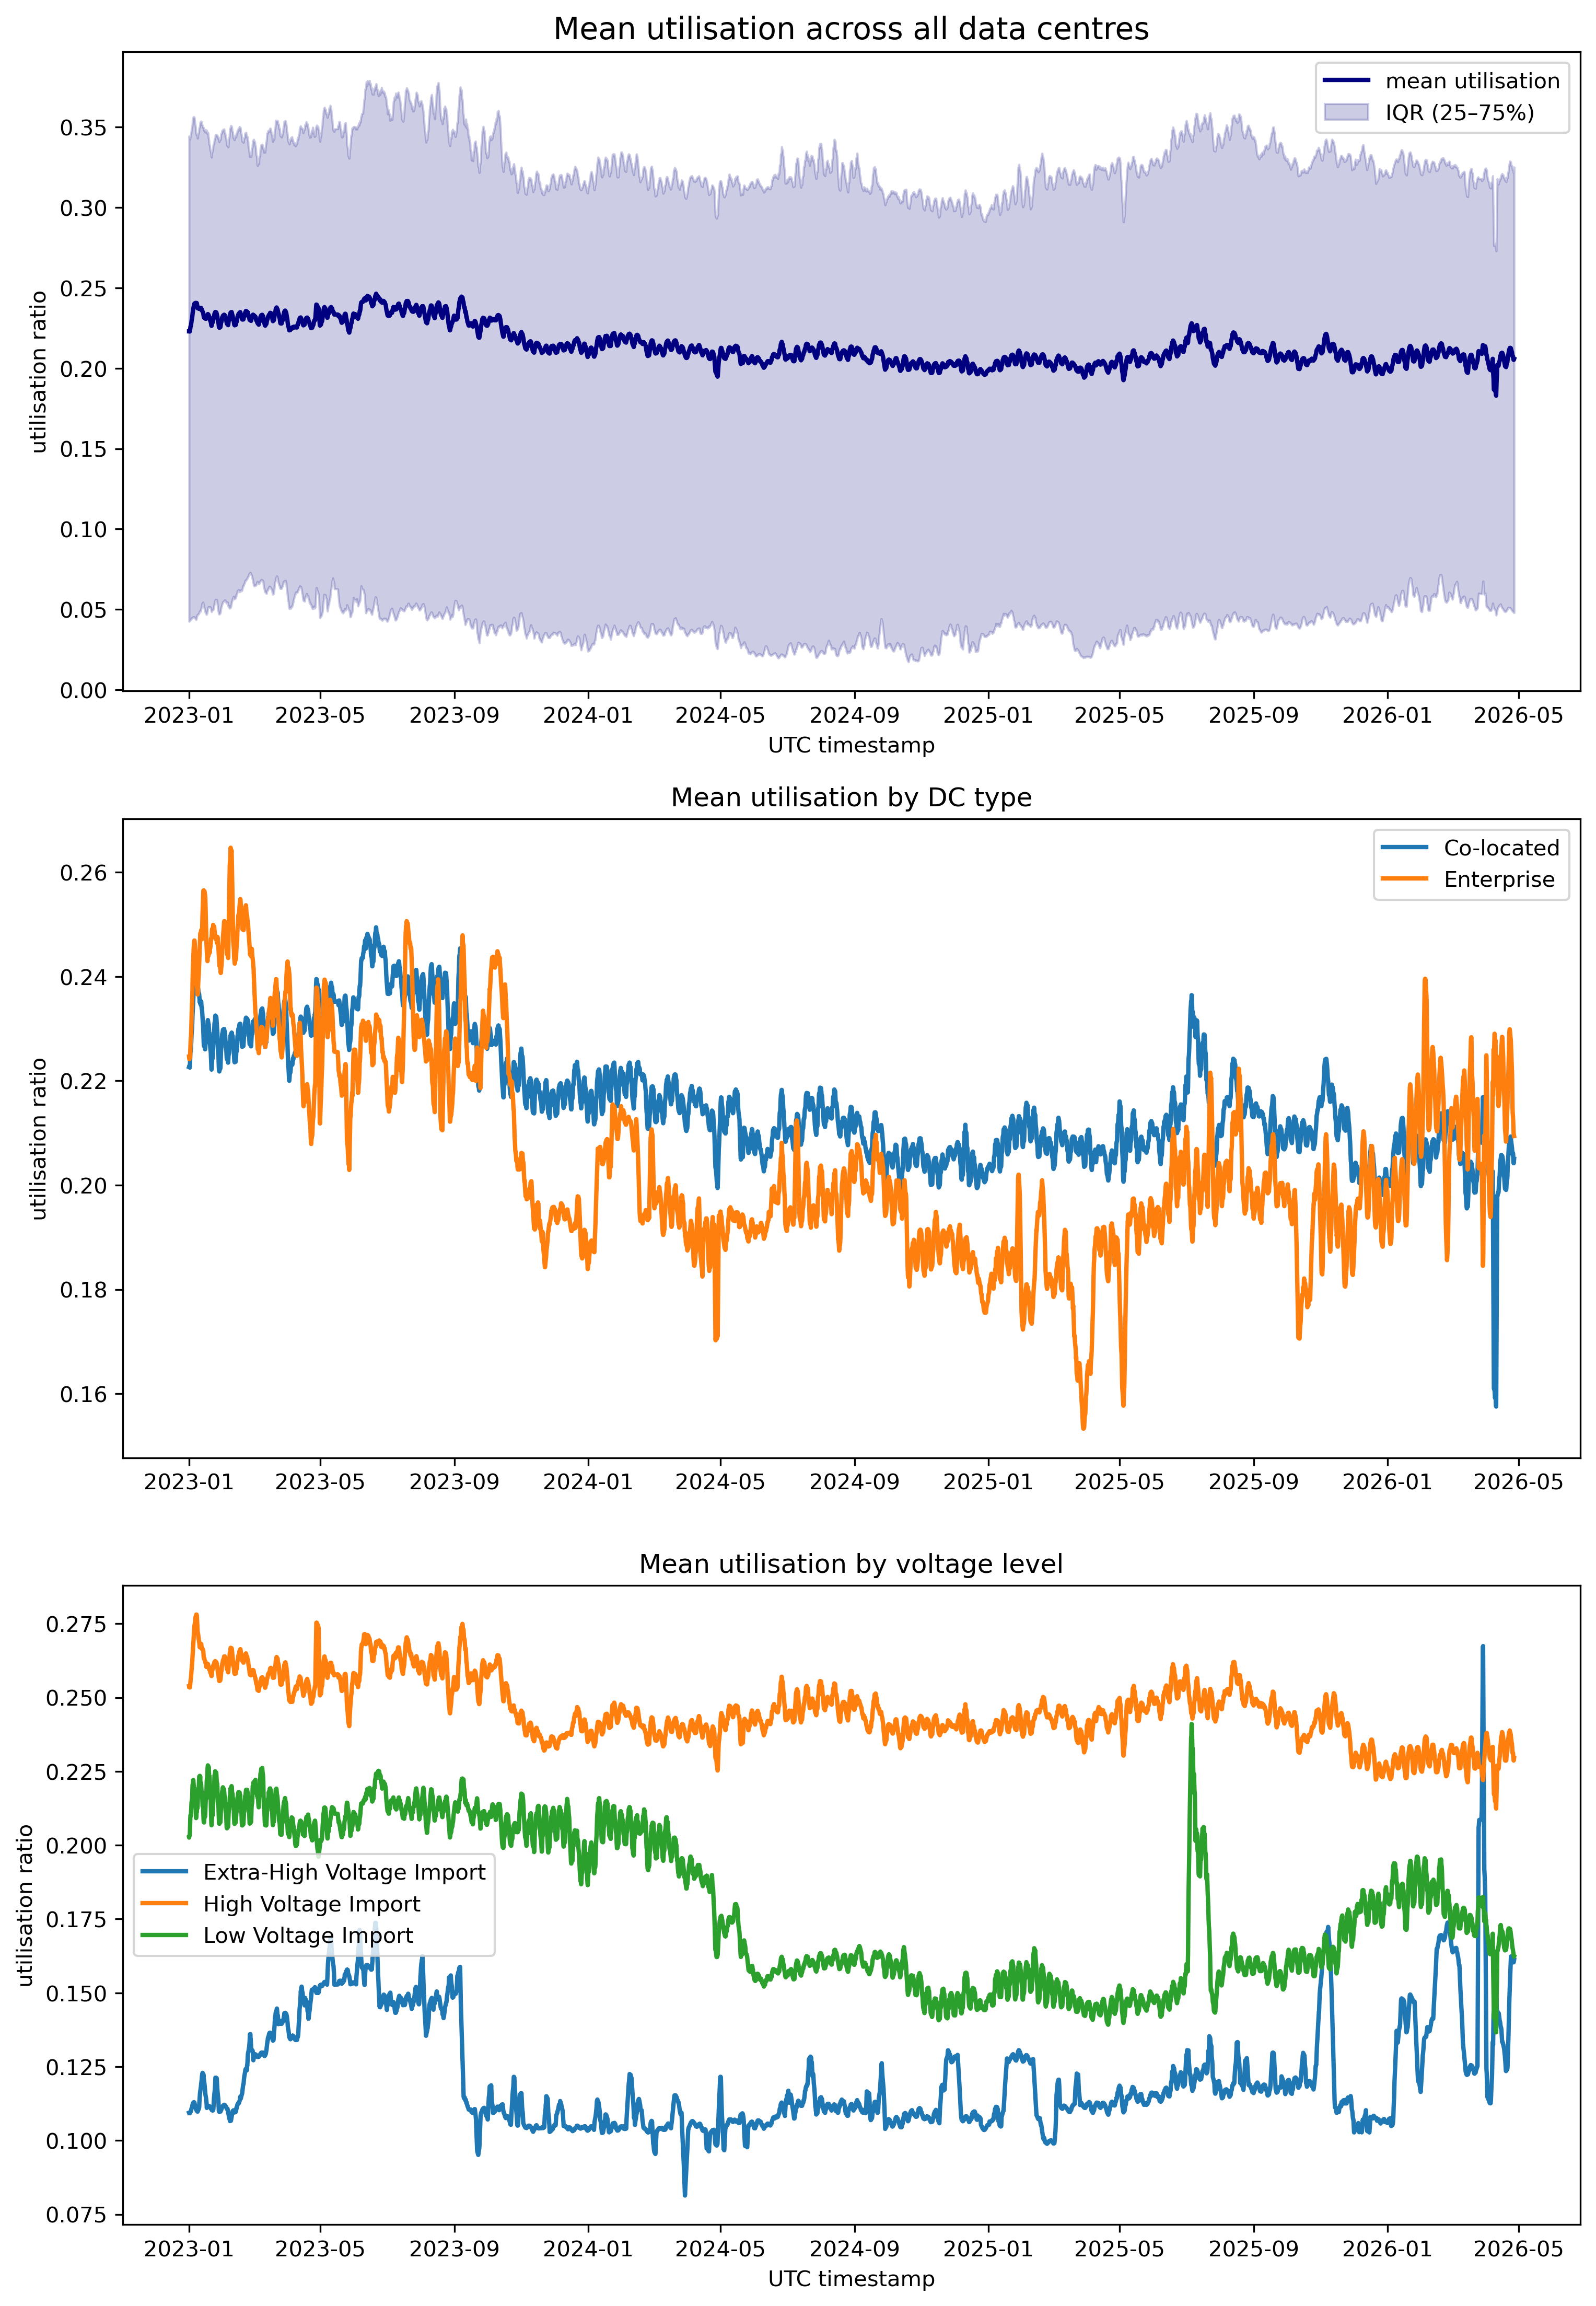

In [101]:
%matplotlib inline
import matplotlib.pyplot as plt

df[VAL] = pd.to_numeric(df[VAL], errors="coerce")
df[TS] = pd.to_datetime(df[TS], errors="coerce")

WINDOW = 150   # number of half-hour steps to average over

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False,dpi=300)

g = df.groupby(TS)[VAL]
mean = g.mean().rolling(WINDOW, center=True, min_periods=1).mean()
lo   = g.quantile(0.25).rolling(WINDOW, center=True, min_periods=1).mean()
hi   = g.quantile(0.75).rolling(WINDOW, center=True, min_periods=1).mean()

axes[0].plot(mean.index, mean.values, color="navy", lw=2, label=f"mean utilisation")
axes[0].fill_between(mean.index, lo, hi, alpha=0.2, color="navy", label="IQR (25–75%)")
axes[0].set_title("Mean utilisation across all data centres",fontsize = 14)
axes[0].set_ylabel("utilisation ratio")
axes[0].set_xlabel("UTC timestamp")
axes[0].legend()

for label, sub in df.groupby(TYPE):
    m = sub.groupby(TS)[VAL].mean().rolling(WINDOW, center=True, min_periods=1).mean()
    axes[1].plot(m.index, m.values, lw=2, label=label)
axes[1].set_title("Mean utilisation by DC type")
axes[1].set_ylabel("utilisation ratio")
axes[1].legend()

for label, sub in df.groupby(VOLT, observed=True):
    m = sub.groupby(TS)[VAL].mean().rolling(WINDOW, center=True, min_periods=1).mean()
    axes[2].plot(m.index, m.values, lw=2, label=label)
axes[2].set_title("Mean utilisation by voltage level")
axes[2].set_ylabel("utilisation ratio")
axes[2].set_xlabel("UTC timestamp")
axes[2].legend()

plt.show()

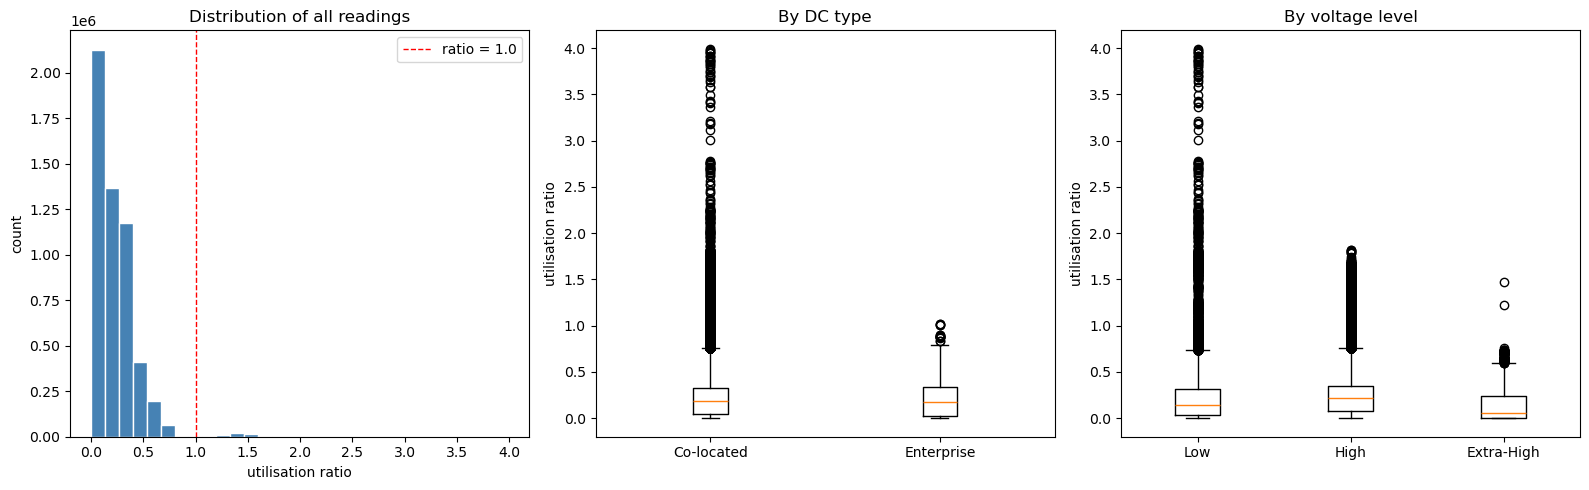

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
axes[0].hist(df[VAL], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(1.0, color="red", ls="--", lw=1, label="ratio = 1.0")
axes[0].set_title("Distribution of all readings")
axes[0].set_xlabel("utilisation ratio")
axes[0].set_ylabel("count")
axes[0].legend()

# boxplot by dc_type
types = sorted(df[TYPE].unique())
axes[1].boxplot([df.loc[df[TYPE] == t, VAL] for t in types], tick_labels=types)
axes[1].set_title("By DC type")
axes[1].set_ylabel("utilisation ratio")

# boxplot by voltage
volts = [v for v in VOLT_ORDER if v in df[VOLT].unique()]
axes[2].boxplot([df.loc[df[VOLT] == v, VAL] for v in volts],
                tick_labels=[v.replace(" Voltage Import", "") for v in volts])
axes[2].set_title("By voltage level")
axes[2].set_ylabel("utilisation ratio")

fig.tight_layout()
plt.show()

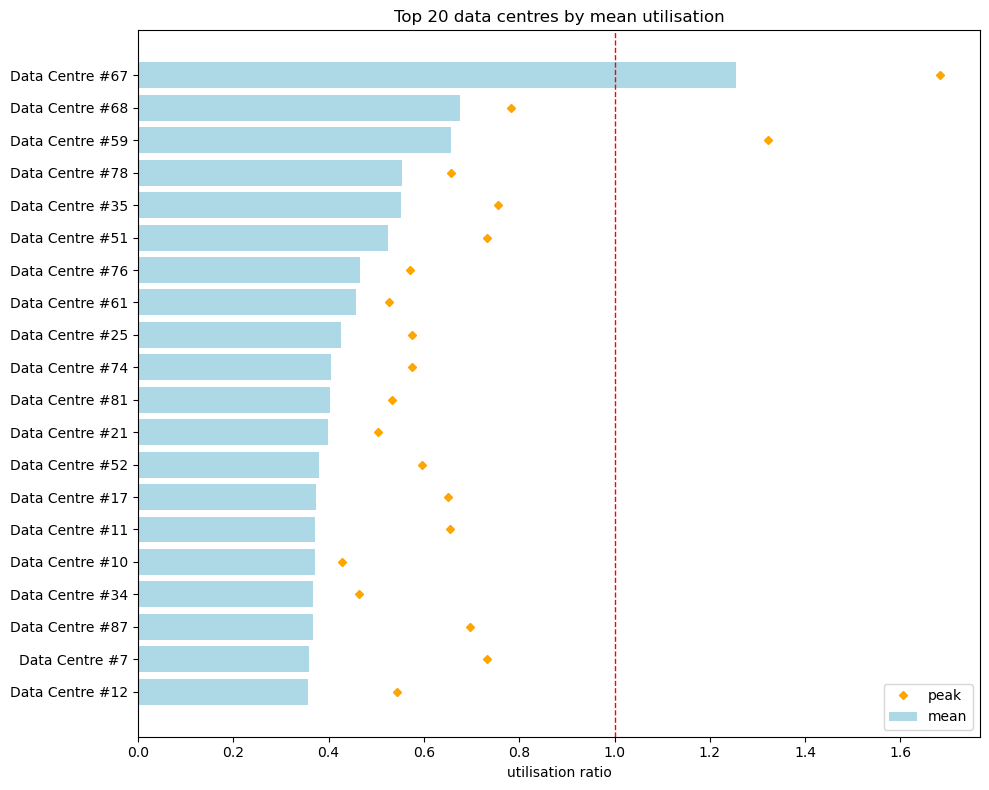

In [45]:
stats = (df.groupby(DC)[VAL]
            .agg(mean="mean", peak="max", n="count")
            .sort_values("mean", ascending=False))

top_n = 20
top = stats.head(top_n)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(top))

ax.barh(y, top["mean"], color="lightblue", label="mean")
ax.plot(top["peak"], y, "D", color="orange", ms=4, label="peak")
ax.set_yticks(list(y))
ax.set_yticklabels(top.index)
ax.axvline(1.0, color="red", ls="--", lw=1)

ax.set_title(f"Top {top_n} data centres by mean utilisation")
ax.set_xlabel("utilisation ratio")
ax.legend()

fig.tight_layout()
plt.show()

utc_timestamp
0 days 00:30:00    57784
1 days 00:30:00        3
3 days 00:30:00        1
2 days 00:30:00        1
Name: count, dtype: int64


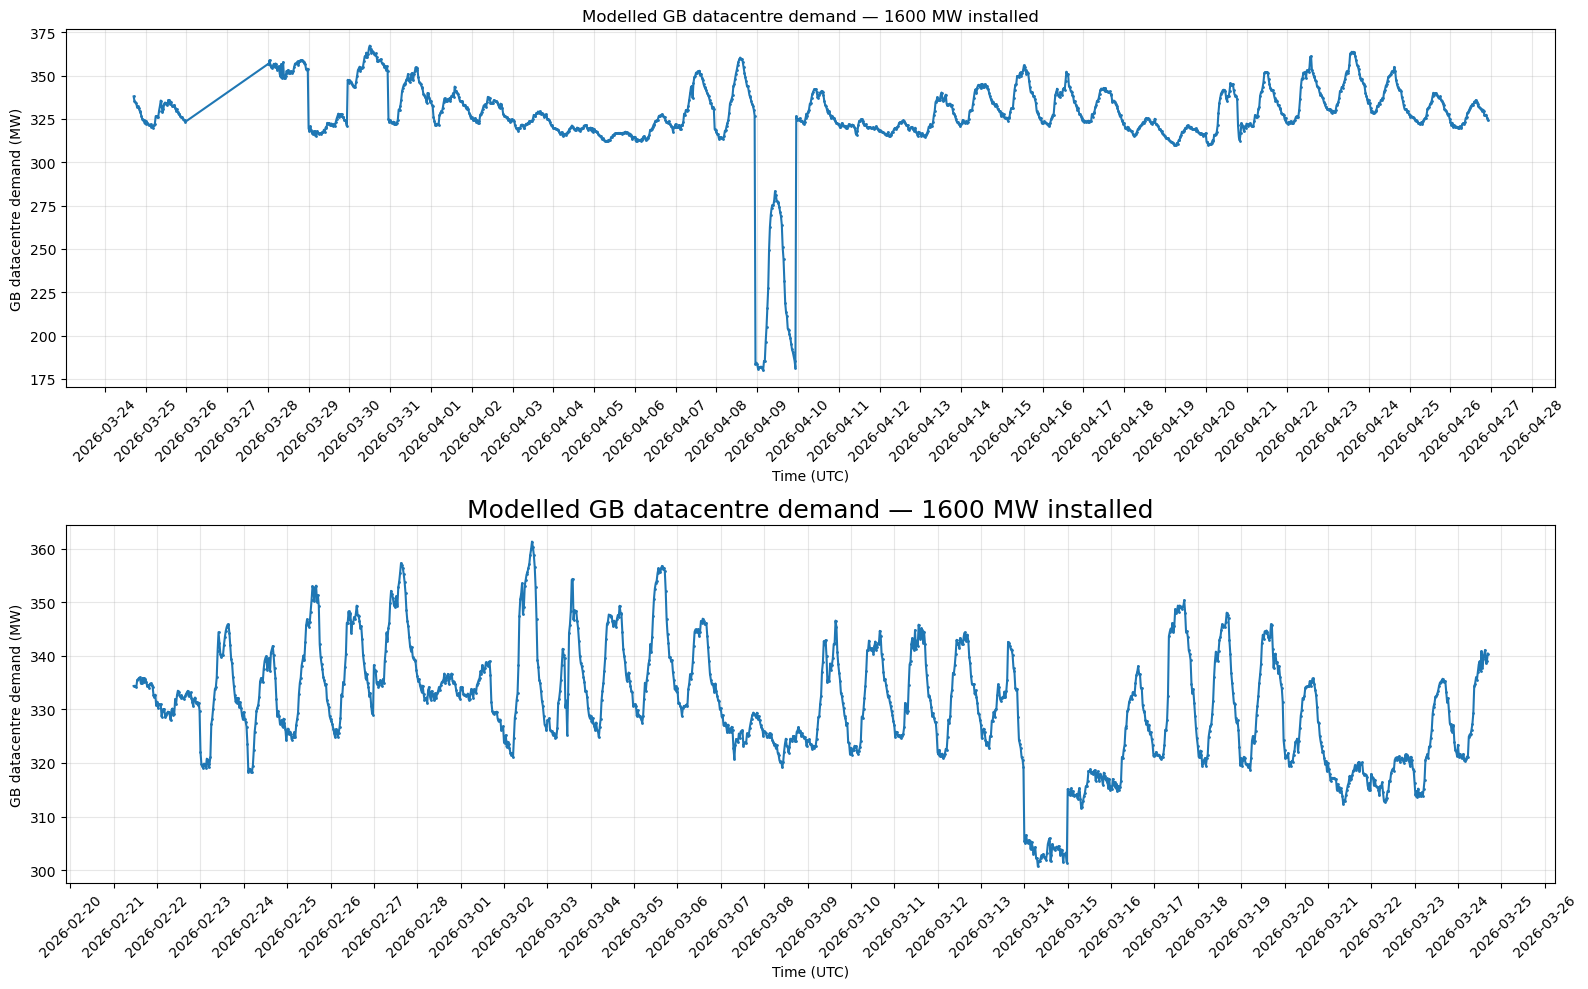

In [84]:
import matplotlib.dates as mdates

df = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")

# renaming columns for ease of use
UTIL = "hh_utilisation_ratio"
DC_NAME = "anonymised_data_centre_name"
DC_TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TIME = "utc_timestamp"
# ordering voltage -> low to extra high
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]
df[TIME] = pd.to_datetime(df[TIME], utc=True)

demand_profile_per_dt = df.groupby(TIME)[UTIL].mean().sort_index()
print(demand_profile_per_dt.index.to_series().diff().value_counts())
# https://www.gov.uk/government/publications/estimate-of-data-centre-capacity-great-britain-2024/estimate-of-data-centre-capacity-great-britain-2024
TOTAL_DC_CAPACITY = 1600 #in MW; 1.6 GW is the current GB capacity

num_modelled_dc = 3
num_dc = df[DC_NAME].nunique()

dc_demand_mw = TOTAL_DC_CAPACITY * demand_profile_per_dt
dc_demand_mw_per_centre = dc_demand_mw / num_modelled_dc

n =1500
dc_demand_mw_top_1500 = dc_demand_mw.iloc[-n:-1]        # points 0–1499
dc_demand_mw_top_3000 = dc_demand_mw.iloc[-2*n:-n]      # points 1500–2999


fig, ax = plt.subplots(2,1, figsize=(16, 10))
ax[0].plot(dc_demand_mw_top_1500.index, dc_demand_mw_top_1500.values, 
        marker="o", 
        markersize=1)
ax[0].set_xlabel("Time (UTC)")
ax[0].set_ylabel("GB datacentre demand (MW)")
ax[0].set_title(f"Modelled GB datacentre demand — {TOTAL_DC_CAPACITY} MW installed")
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis="x", labelrotation=45)

ax[0].xaxis.set_major_locator(mdates.DayLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))



ax[1].plot(dc_demand_mw_top_3000.index, dc_demand_mw_top_3000.values, 
        marker="o", 
        markersize=1)
ax[1].set_xlabel("Time (UTC)")
ax[1].set_ylabel("GB datacentre demand (MW)")
ax[1].set_title(f"Modelled GB datacentre demand — {TOTAL_DC_CAPACITY} MW installed",fontsize=18)
ax[1].grid(True, alpha=0.3)
ax[1].tick_params(axis="x", labelrotation=45)

ax[1].xaxis.set_major_locator(mdates.DayLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.tight_layout()
plt.show()


In [47]:
import pypsa

n = pypsa.Network("../resources/network/Martas_Q2_zonal_2020_solved.nc")
print(n.buses[["x", "y", "carrier"]].to_string())

INFO:pypsa.network.io:Imported network 'Martas_Q2_zonal_2020 (Full)' has buses, carriers, generators, links, loads, storage_units, sub_networks


                                                    x             y carrier
name                                                                       
Z10                                     508272.452661  3.610900e+05      AC
Z11                                     424022.376665  2.968537e+05      AC
Z12                                     567375.298902  2.645857e+05      AC
Z13                                     334888.007379  2.135753e+05      AC
Z14                                     527920.552208  1.835088e+05      AC
Z15                                     597049.193309  1.607791e+05      AC
Z16                                     489487.333776  1.274007e+05      AC
Z17                                     287169.770199  9.649068e+04      AC
Z1_1                                    442009.410351  1.166134e+06      AC
Z1_2                                    114059.413136  9.052043e+05      AC
Z1_3                                    256554.246745  9.157052e+05      AC
Z1_4        

---
---
## <span style=color:yellow> **MARTA'S IMPLEMENTATION**
---
---

In [48]:
# import requests, os, pandas as pd

# os.environ["API_KEY"] = "3330fdf9f91aadb09332a4131567fee6f29e327c88a6227401edf5a6"
# headers = {"Authorization": f"Apikey {os.environ['API_KEY']}"}
# url = ("https://ukpowernetworks.opendatasoft.com/api/explore/v2.1/"
#        "catalog/datasets/ukpn-data-centre-demand-profiles/exports/json?lang=en")
# r = requests.get(url, headers=headers)
# print(r.status_code)
# df = pd.DataFrame(r.json())

#### **Import libraries required**

In [49]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import plotly
import seaborn as sb
import matplotlib.pyplot as plt


### <span style=color:pink> **Get data(frames) needed for the project**

#### **Data centre demand profiles**

In [50]:
df_dc_demand_profile = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")
# df_dc_demand_profile.head()
# assigning df column names to something shorter for ease
UTIL = "hh_utilisation_ratio"
DC_NAME = "anonymised_data_centre_name"
DC_TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TIME = "utc_timestamp"
# ordering voltage -> low to extra-high
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]
# convert tot date/time
df_dc_demand_profile[TIME] = pd.to_datetime(df_dc_demand_profile[TIME], utc=True)
df_dc_demand_profile

,cleansed_voltage_level,anonymised_data_centre_name,dc_type,local_timestamp,utc_timestamp,hh_utilisation_ratio
0,High Voltage Import,Data Centre #70,Co-located,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.033600
1,Low Voltage Import,Data Centre #72,Enterprise,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.000000
2,Low Voltage Import,Data Centre #73,Co-located,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.127279
3,Low Voltage Import,Data Centre #77,Co-located,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.321519
4,Low Voltage Import,Data Centre #78,Co-located,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.501500
...,...,...,...,...,...,...
5390359,Extra-High Voltage Import,Data Centre #32,Co-located,2026-02-18T06:00:00+00:00,2026-02-18 06:00:00+00:00,0.000000
5390360,High Voltage Import,Data Centre #33,Co-located,2026-02-18T06:00:00+00:00,2026-02-18 06:00:00+00:00,0.053160
5390361,High Voltage Import,Data Centre #36,Co-located,2026-02-18T06:00:00+00:00,2026-02-18 06:00:00+00:00,0.183600
5390362,High Voltage Import,Data Centre #4,Co-located,2026-02-18T06:00:00+00:00,2026-02-18 06:00:00+00:00,0.242749


#### **Population data**

In [51]:
# https://www.worldometers.info/population/largest-cities-in-uk/
df_population = pd.read_csv("../data/data_centres/uk_largest_cities.csv")

df_population = df_population.drop(columns=['Global Rank'])
df_population.head()

,Rank,Urban Area,Population Estimate (2025),1 Year Change (over 2024),Land Area (Km2),Density (P/Km2),Projections (2030),Projections (2050),Easting,Northing
0,1,London,"10,416,420",0.82%,"1,646","6,328","10,766,831","11,868,905",530029,180380
1,2,Birmingham,"2,631,757",0.54%,671,"3,922","2,689,574","2,810,468",407540,287592
2,3,Manchester,"2,535,427",0.38%,741,"3,422","2,567,727","2,638,194",383997,398258
3,4,Liverpool,"1,227,470",0.53%,369,"3,326","1,241,135","1,254,523",334179,390634
4,5,Leeds,"1,065,607",0.45%,323,"3,299","1,086,815","1,109,261",429796,433927


#### **FES data**

In [52]:
url = ("https://api.neso.energy/dataset/2c15c755-d8fe-4229-9169-3b6dd7c88fec/"
       "resource/300c07b9-baeb-4411-bc40-987cbb4aec0b/download/fes2025_ed1_v006.csv")
df_neso_energy_demand = pd.read_csv(url)

# print(df_neso_energy_demand.head(20))

df_fes_filtered = df_neso_energy_demand[
    (df_neso_energy_demand['Data item'] == 'Data Centre Demand') |
    (df_neso_energy_demand['Data item'] == 'GBFES System Demand: Total')
]
df_fes_filtered

,Aggregation Level,Data item,Unit,Pathway,Fuel,Peak/ Annual/ Minimum,2023,2024,2025,2026,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,1,GBFES System Demand: Total,GWh,Hydrogen Evolution,Electricity,Annual [Fiscal],286780.0,289650.0,293394.0,297512.0,...,629181.0,658165.0,691892.0,720585.0,732957.0,748081.0,770705.0,778236.0,795993.0,797120.0
1,1,GBFES System Demand: Total,GWh,Electric Engagement,Electricity,Annual [Fiscal],286780.0,289650.0,291698.0,296073.0,...,644531.0,672190.0,694708.0,709671.0,724440.0,737930.0,752313.0,766439.0,776227.0,784736.0
2,1,GBFES System Demand: Total,GWh,Falling Behind,Electricity,Annual [Fiscal],286780.0,289650.0,295231.0,298512.0,...,450011.0,464557.0,477519.0,490691.0,504316.0,516137.0,526834.0,537853.0,548276.0,558750.0
3,1,GBFES System Demand: Total,GWh,Holistic Transition,Electricity,Annual [Fiscal],286780.0,289650.0,290891.0,294991.0,...,582761.0,602352.0,621073.0,635458.0,654296.0,670284.0,681236.0,691034.0,700725.0,705223.0
4,1,GBFES System Demand: Total,GWh,Ten Year Forecast,Electricity,Annual [Fiscal],286780.0,289650.0,292075.0,295108.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,5,Data Centre Demand,GWh,Hydrogen Evolution,Electricity,Annual [Fiscal],7400.0,7538.0,8651.0,9735.0,...,39705.0,41216.0,42709.0,44132.0,45430.0,46664.0,47856.0,49012.0,50139.0,51242.0
121,5,Data Centre Demand,GWh,Electric Engagement,Electricity,Annual [Fiscal],7400.0,7565.0,9343.0,10912.0,...,56831.0,58855.0,60678.0,62329.0,63884.0,65356.0,66757.0,68098.0,69352.0,70562.0
122,5,Data Centre Demand,GWh,Falling Behind,Electricity,Annual [Fiscal],7400.0,7518.0,8014.0,8400.0,...,24696.0,25407.0,26070.0,26704.0,27357.0,27986.0,28594.0,29184.0,29766.0,30334.0
123,5,Data Centre Demand,GWh,Holistic Transition,Electricity,Annual [Fiscal],7400.0,7565.0,9259.0,10864.0,...,51867.0,53796.0,55559.0,57165.0,58687.0,60136.0,61519.0,62845.0,64101.0,65317.0
124,5,Data Centre Demand,GWh,Ten Year Forecast,Electricity,Annual [Fiscal],7400.0,7738.0,8129.0,8929.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Create sub-functions to complete easy tasks within main functions**

##### ✅ **Fully Working Functions:**

In [53]:
def _nearest_bus(base_network: pypsa.Network, easting, northing, nearest_n_buses = False):
    '''
    This function finds the nearest bus for the specified location (easting / northing).

    Args:
        - base network: the pypsa baseline network to add data centres to
        - easting and northing of the preferred location
    
    Returns:
        - bus that has to closest to the specified location
    '''

    # get AC buses only
    ac_bus = base_network.buses[(base_network.buses.carrier == "AC") & 
                                (~base_network.buses.index.str.contains("HVDC|external", case=False))
                                ]

    # find the distance between selected point and the AC buses
    distance = np.sqrt((ac_bus.x-easting)**2 + (ac_bus.y-northing)**2)
    # select the one with minimum distance
    nearest_bus = distance.idxmin()
    if nearest_n_buses:
        return distance.sort_values(ascending = True)
    
    return nearest_bus

def _get_timestep_hours(index: pd.DatetimeIndex, default: float = 1) -> float:
    '''
    This function takes the snapshot of selected time and converts that into hours.

    Args:
        - index: 
        - default: default state in case the number of hours 
    Returns:
        - 
    '''
    if index is None or len(index) < 2:
        return default
    delta_hours = (index[1] - index[0]).total_seconds() / 3600.0
    return delta_hours if delta_hours > 0 else default

def _get_dc_demand_profile(return_mean_utilisation = False):
    '''
    This function returns the demand profile (per half-hourly timestep), based on the UKPN data.
    Returns:
        - demand_profile_per_dt: returns the full demand profile, averaged across 94 data centres in the UKPN region, 
        for each half-hour time-step 01-01-2023–26-04-2026.
        - mean utilisation: OPTIONAL, instead of returning the demand profile for each timestep, returns the overall mean utilisation value.
    '''
    df_dc_demand_profile = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")
  
    # assigning df column names to something shorter for ease
    UTIL = "hh_utilisation_ratio"
    TIME = "utc_timestamp"
    
    # convert to date/time
    df_dc_demand_profile[UTIL] = pd.to_numeric(df_dc_demand_profile[UTIL], errors="coerce")
    df_dc_demand_profile[TIME] = pd.to_datetime(df_dc_demand_profile[TIME], errors="coerce", utc=True)

    demand_profile_per_dt = df_dc_demand_profile.groupby(TIME)[UTIL].mean().sort_index()

    if return_mean_utilisation:
        mean = demand_profile_per_dt.mean()
        return mean

    return demand_profile_per_dt

def _get_total_dc_demand_FES_gw(year: int, scenario: str, return_GWh = False, mean_utilisation = _get_dc_demand_profile(return_mean_utilisation=True)):
    '''
    This function takes the total load demand - wether it's from historic data or Future Energy Scenario (FES),
    and calculates the DC demand as a fraction of the total demand.

    Args:
        - total_gwh: GB's total load demand in GWh
        - fraction: assumed % of the total demand that data centres account for (0.9–2%, predicted). Default value: 2% = 0.02
    Returns:
        - total_dc_gw: the total capacity of data centres, as predicted by FES, in GW
        - total_dc_gwh: 
    '''
    # list available scenarios
    scenario_list = ['Hydrogen Evolution', 'Holistic Transition', 'Falling Behind', 'Electric Engagement']
    if scenario not in scenario_list:
        raise NameError("Wrong scenario name. Available scenarios:", scenario_list)
    
    elif year <= 2022 or year > 2050:
        raise ValueError("This is a module for Future Scenarios. Enter year > 2022, up to 2050.")
    else:
        df_fes = pd.read_csv("../data/data_centres/fes2025_ed1_v006.csv")

        # take the data from column matching year choice & row = desired scenario for data centre demand
        total_dc_gwh = float(df_fes[str(year)][
            (df_fes['Data item'] == 'Data Centre Demand') &
            (df_fes['Pathway'] == scenario)].iloc[0])
        total_dc_gw = total_dc_gwh / 8760 / mean_utilisation

    if return_GWh:
        return total_dc_gwh

    return total_dc_gw


- [x] Check how to get mean utilisation for say the past year and 
- [x] compare with the overall utilisation (especting higher value)

In [54]:
import pandas as pd
df = _get_dc_demand_profile()  

mean_2023 = df.loc["2023-01-01":"2023-12-31"].mean()
mean_last_year = df.loc["2025-04-27":"2026-04-26"].mean()  

In [55]:
print(mean_2023)
print(mean_last_year)

0.22900099950564495
0.20817470953689624


In [56]:
def _convert_DC_demand_profile_to_GWh(total_dc_capacity_gw: float):
    '''
    This function converts the peak data centre capacity (GW) to the demand time series (GWh) and total demand (GWh).
    Args:
        - total_dc_capacity_gw: Peak data centre capacity (GW)
    Returns:
        - dc_time_series_demand_gwh: demand in GWh as half-hourly time series
        - total_dc_demand_gwh: total data centre demand over selected period of time
    '''

    # get the half-hourly demand profile
    demand_profile_per_dt = _get_dc_demand_profile()
    mean_utilisation = demand_profile_per_dt.mean()

    dc_demand_gw = total_dc_capacity_gw * demand_profile_per_dt

    timestep_hours = _get_timestep_hours(dc_demand_gw.index)
    dc_time_series_demand_gwh = dc_demand_gw * timestep_hours
    total_dc_demand_gwh = total_dc_capacity_gw  * mean_utilisation * 8760

    return dc_time_series_demand_gwh, total_dc_demand_gwh

def _get_total_dc_demand_MANUAL_gw(year: int, dc_prediction_2030_gw = 6.0):
    '''
    This function predicts a compound increase in DC capacity, based on the prediction made for the 
    2025 -> 2030 increase (1.6 GW -> 6.0 GW).
    This load will be added on top of the overall FES-predicted load / demand.
    Args:
        - year: a year which you want to predict the capacity for
        - dc_prediciton_20230_gw: used to calculate rate; assumed to be the current 6.0 GW by default, 
            but can be set to a more pessimistic (4.0 GW) or optimistic (8.0 GW)
            scenario to affect the rate and predict pessimistic/optmistic future scenarios overall.
    Returns:
        - total_dc_gw: the total capacity of the data centres
    '''
    
    # 6.0 (GW planned for 2030) = 1.6 (GW as of 2025) * (1+rate)**5  -> rate = (6.0/1.6)**1/5 - 1
    rate = (dc_prediction_2030_gw / 1.6) ** (1/5) - 1 
    total_dc_gw = 1.6 * (1+rate)**(year-2025)

    return total_dc_gw

#### **TESTS - get demand profile**

In [57]:
_get_dc_demand_profile(return_mean_utilisation=True)

0.21393068434677415

#### **TESTS - Manual demand vs FES**

In [58]:
test_demand = _get_total_dc_demand_MANUAL_gw(year = 2028, dc_prediction_2030_gw = 12.0)
_, manual_gwh = _convert_DC_demand_profile_to_GWh(total_dc_capacity_gw = test_demand)
print(test_demand)
print(manual_gwh)


5.359900661298289
10044.629616559889


In [59]:
idx = _get_dc_demand_profile().index
print(idx.min(), idx.max(), (idx.max()-idx.min()).days)

2023-01-01 00:00:00+00:00 2026-04-26 22:30:00+00:00 1211


In [60]:
test = _get_total_dc_demand_FES_gw(year = 2028, scenario = 'Falling Behind', return_GWh = False)
print(test)
gwh = _get_total_dc_demand_FES_gw(year = 2028, scenario = 'Falling Behind', return_GWh = True)
print(gwh)

5.74376287833438
10764.0


---
---
## <span style="color:yellow">       **Create functions for the main workflow** </span>
---
---

In [61]:
# defining test networks:
Q1_zonal = pypsa.Network("../resources/network/Martas_Q1_zonal_2020.nc")
Q2_zonal = pypsa.Network("../resources/network/Martas_Q2_zonal_2020.nc")
Q3_zonal = pypsa.Network("../resources/network/Martas_Q3_zonal_2020.nc")
Q4_zonal = pypsa.Network("../resources/network/Martas_Q4_zonal_2020.nc")

Jan_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Jan.nc")
Nov_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Nov.nc")
Aug_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Aug.nc")
Apr_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Apr.nc")

HT35_flex = pypsa.Network("../resources/network/HT35_flex.nc")

INFO:pypsa.network.io:Imported network 'Martas_Q1_zonal_2020 (Full)' has buses, carriers, generators, links, loads, storage_units
INFO:pypsa.network.io:Imported network 'Martas_Q2_zonal_2020 (Full)' has buses, carriers, generators, links, loads, storage_units
INFO:pypsa.network.io:Imported network 'Martas_Q3_zonal_2020 (Full)' has buses, carriers, generators, links, loads, storage_units
INFO:pypsa.network.io:Imported network 'Martas_Q4_zonal_2020 (Full)' has buses, carriers, generators, links, loads, storage_units
INFO:pypsa.network.io:Imported network 'HT35_clustered_kmeans_1_week_Jan (Clustered)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'HT35_clustered_kmeans_1_week_Nov (Clustered)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'HT35_clustered_kmeans_1_week_Aug (Clustered)' has buses, carriers, generators, lines, li

#### **TESTS - network**

In [62]:
# _nearest_bus(base_network = zonal, easting=290000, northing=870000, nearest_n_buses = True)

#### **Allocation - north**

In [63]:
import pandas as pd
import pypsa
import logging
import numpy as np
import xarray as xr
from pathlib import Path
import sys
from typing import Optional, Dict, Any

def allocate_north_scotland(total_dc_gw: float, base_network: pypsa.Network, logger, single_dc_mw: float = 300) -> pd.Series:
    '''
    Allocation model placing ALL specified capacity in the North of Scotland as close to 290000, 870000 point (easting, northing) as possible.
    The model selectes n closest buses to place DCs on, where n is the total number of DCs.

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW. Data centres won't have exactly this capcity, 
        but rather this + the evenly distributed remaining capacity after calculating the total number of DCs - rounding down the total capacity / single_dc_mw
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''

    # number of full-capacity data centres that fit into the total capcity specified
    num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))
    # remainding capacity of the data centres
    remaining_dc_mw = total_dc_gw * 1000 - num_dc*single_dc_mw
    print(f'Last DC capacity = {remaining_dc_mw:.1f}')
    # total number of data centres added - +1 if total caapcity not divisible by single_dc_mw
    new_dc_mw = round(single_dc_mw + remaining_dc_mw / num_dc, 2)

    # the list of available buses closest to the selected point in north of scotland, 
    # sorted by distance (closest -> furthest)
    bus_list = _nearest_bus(base_network, 290000, 870000, nearest_n_buses=True)
    bus_list = bus_list.head(num_dc)  # keeping only

    # set initial state of the dc capacity on buses - 0.0
    dc_allocation = pd.Series(0.0, index = base_network.buses.index)
    dc_allocation.loc[bus_list.index[:num_dc]] = new_dc_mw # assign DC capacities only to the closest n buses
    
    print(f"Allocated {dc_allocation.sum():.1f} GW in the north of Scotland ONLY ({num_dc} DCs of {new_dc_mw} MW).")
    
    return dc_allocation



#### **TESTS - north**

In [64]:
# allocate_north_scotland(total_dc_gw = 1.9, base_network = zonal, logger = logging.Logger)

#### **Allocation - current split**

In [65]:
def allocate_current_split_scaled(total_dc_gw: float, base_network: pypsa.Network, logger, single_dc_mw: float=300) -> pd.Series:
    '''
    This scenario takes into account the current capacity split across the country and keeps the 
    exact ratio of the capacities across regions: 
        - Scotland + North East + North West = 99 MW; 
        - Yorkshire and the Humber + Midlands + Wales = 194; 
        - London = 1,048; 
        - South West + South East + East = 225.

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW. Data centres won't have exactly this capcity, 
        but rather this + the evenly distributed remaining capacity after calculating the total number of DCs - rounding down the total capacity / single_dc_mw
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''
    # values based on: 
    # https://www.gov.uk/government/publications/estimate-of-data-centre-capacity-great-britain-2024/estimate-of-data-centre-capacity-great-britain-2024
    total_current_mw = 1566
    scotland_fraction = 99 / total_current_mw
    midlands_fraction = 194 / total_current_mw
    london_fraction = 1048 / total_current_mw
    england_fraction = 225 / total_current_mw

    # create lists of fractions, eastings and northings (same order)
    fractions = [scotland_fraction, midlands_fraction, london_fraction, england_fraction]
    eastings = [290000, 430000, 530000, 450000]
    northings = [870000, 400000, 180000, 170000]

    # initialise for the loop
    dc_allocation = pd.Series(0.0, index = base_network.buses.index)
    total_num_dc = 0
    dc_mw = []

    for i, fraction in enumerate(fractions):
        current_mw = total_dc_gw * 1000 * fraction

        if current_mw > single_dc_mw:
            num_dc = int(np.floor(current_mw / single_dc_mw ))
            remaining_dc_mw = current_mw - num_dc * single_dc_mw
            new_dc_mw = round(single_dc_mw + remaining_dc_mw / num_dc, 2)
        else: 
            new_dc_mw = round(current_mw, 2)
            num_dc = 1
        
        bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
        bus_list = bus_list.head(num_dc)

        already_used = (dc_allocation.loc[bus_list.index[:num_dc]] != 0.0).any()
        if already_used:
            print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
        dc_allocation.loc[bus_list.index[:num_dc]] += new_dc_mw # assign DC capacities only to the closest n buses
        
        total_num_dc =+ num_dc
        dc_mw.append(new_dc_mw)
        print(f"Allocated {new_dc_mw * num_dc:.2f} MW ({num_dc} DC(s) of {new_dc_mw} MW).")
    
    print(f"Allocated {dc_allocation.sum():.2f} MW across the  ({total_num_dc} DCs of {dc_mw} MW).")
    
    return dc_allocation

#### **TESTS - current split**

In [66]:
_get_total_dc_demand_FES_gw(year = 2028, scenario='Falling Behind', mean_utilisation=_get_dc_demand_profile(return_mean_utilisation=True))

5.74376287833438

In [67]:
# allocate_current_split_scaled(total_dc_gw = _get_total_dc_demand_FES(year = 2028, scenario='Holistic Transition'), base_network = clustered, logger = logging.Logger, single_dc_mw=800)

In [68]:
df_population = pd.read_csv("../data/data_centres/uk_largest_cities.csv")
df_population = df_population.drop(columns=['Global Rank'])
df_population.head(10)

,Rank,Urban Area,Population Estimate (2025),1 Year Change (over 2024),Land Area (Km2),Density (P/Km2),Projections (2030),Projections (2050),Easting,Northing
0,1,London,"10,416,420",0.82%,"1,646","6,328","10,766,831","11,868,905",530029,180380
1,2,Birmingham,"2,631,757",0.54%,671,"3,922","2,689,574","2,810,468",407540,287592
2,3,Manchester,"2,535,427",0.38%,741,"3,422","2,567,727","2,638,194",383997,398258
3,4,Liverpool,"1,227,470",0.53%,369,"3,326","1,241,135","1,254,523",334179,390634
4,5,Leeds,"1,065,607",0.45%,323,"3,299","1,086,815","1,109,261",429796,433927
5,6,Glasgow,"970,320",0.31%,297,"3,267","978,925","987,250",259176,665740
6,7,Newcastle upon Tyne,"760,969",0.42%,229,"3,323","770,661","784,878",424561,564921
7,8,Nottingham,"649,610",0.37%,175,"3,712","657,280","670,317",456658,340045
8,9,Bristol,"615,703",0.35%,133,"4,629","622,438","635,268",359247,173000
9,10,Sheffield,"549,695",0.46%,153,"3,593","566,791","583,953",435346,387270


#### **Allocation - population**

In [69]:
def allocate_population_density_weighted(total_dc_gw: float, base_network: pypsa.Network, logger, single_dc_mw: float = 300) -> pd.Series:
    '''
    This scenario takes into account the highest population density points across the UK 
    and places the data centre capacities ~proportionally at those locations:
        - London 6 first data centres
        - Birmingham 7th & 8th DC
        - Manchester 9th & 10th DC
        - remaining DCs 1 per city

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW. Data centres won't have exactly this capcity, 
        but rather this + the evenly distributed remaining capacity after calculating the total number of DCs - rounding down the total capacity / single_dc_mw
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''
    # https://www.worldometers.info/population/largest-cities-in-uk/
    df_population = pd.read_csv("../data/data_centres/uk_largest_cities.csv")
    df_population = df_population.drop(columns=['Global Rank'])
  
    eastings = df_population["Easting"].tolist()
    northings = df_population["Northing"].tolist()

    dc_allocation = pd.Series(0.0, index = base_network.buses.index)
    total_num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))
    remaining_dc_mw = (total_dc_gw * 1000 - total_num_dc * single_dc_mw) / total_num_dc
    current_dc_mw = round(single_dc_mw + remaining_dc_mw, 2)
    
    if total_num_dc <= 6:
        print('6')
        # first 6 to be placed near London
        bus_list = _nearest_bus(base_network, eastings[0], northings[0], nearest_n_buses=True)
        bus_list = bus_list.head(total_num_dc)
        dc_allocation.loc[bus_list.index[:total_num_dc]] += current_dc_mw

    elif total_num_dc <= 8:
        # 6 in London + 2 in Birmingham
        print('8')
        for i in range (0,2):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(total_num_dc)

            already_used = (dc_allocation.loc[bus_list.index[:total_num_dc]] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index[:num_dc]] += current_dc_mw

    elif total_num_dc <= 10:
        # 6 in London + 2 in Birmingham + 2 in Manchester
        print('10')
        for i in range (0,3):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(total_num_dc)

            already_used = (dc_allocation.loc[bus_list.index[:total_num_dc]] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index[:num_dc]] += current_dc_mw

    else:
        # 6 in London + 2 in Birmingham + 2 in Manchester + rest, as many as there are, one DC in each city
        for i in range (0,total_num_dc):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(total_num_dc)

            already_used = (dc_allocation.loc[bus_list.index[:total_num_dc]] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index[:total_num_dc]] += current_dc_mw

    return dc_allocation

#### **TESTS - population**

In [70]:
# allocate_population_density_weighted(total_dc_gw = _get_total_dc_demand_FES(year = 2028, scenario='Holistic Transition', mean_utilisation=0.8), base_network = zonal, logger = logging.Logger, single_dc_mw=300)

#### **~~Create a 3-year cycle for demand profiles~~**

In [87]:
def _build_dc_reference_profile(start="2023-01-01", end="2025-12-31") -> pd.Series:
    profile = _get_dc_demand_profile().loc[start:end]

    key = pd.MultiIndex.from_arrays([
        profile.index.month,
        profile.index.dayofweek,     # 0=Mon ... 6=Sun, instead of day-of-month
        profile.index.hour,
        profile.index.minute
    ], names=["month", "dayofweek", "hour", "minute"])

    reference = profile.groupby(key).mean()
    return reference

In [88]:
_build_dc_reference_profile()

(1, 0, 0, 0)       0.213234
(1, 0, 0, 30)      0.212323
(1, 0, 1, 0)       0.213349
(1, 0, 1, 30)      0.212736
(1, 0, 2, 0)       0.213475
                     ...   
(12, 6, 21, 30)    0.201598
(12, 6, 22, 0)     0.201484
(12, 6, 22, 30)    0.201316
(12, 6, 23, 0)     0.201232
(12, 6, 23, 30)    0.200613
Name: hh_utilisation_ratio, Length: 4032, dtype: float64

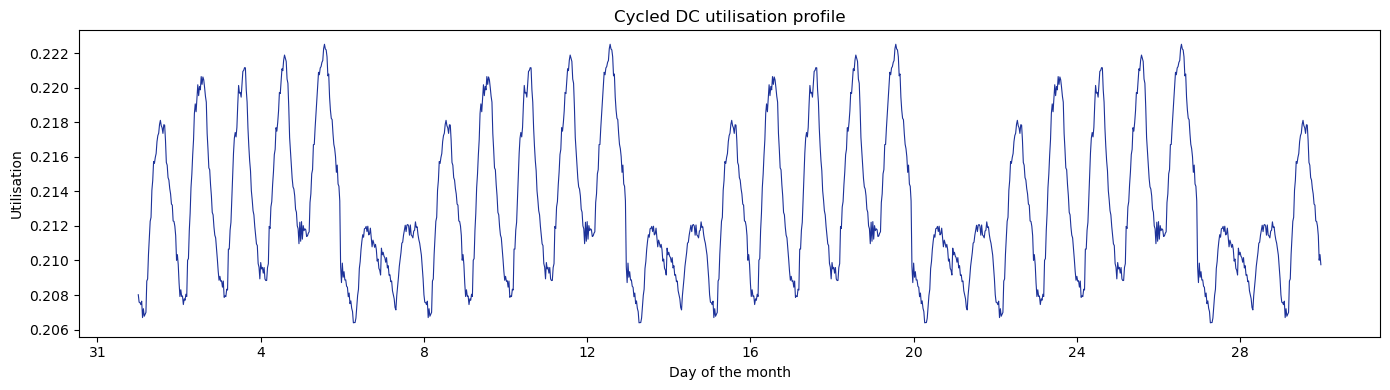

In [98]:
reference = _build_dc_reference_profile()

target = pd.date_range("2030-04-01", "2030-04-29 23:30", freq="30min", tz="UTC")
target_key = pd.MultiIndex.from_arrays(
    [target.month, target.dayofweek, target.hour, target.minute],
    names=["month", "dayofweek", "hour", "minute"]
)
cycled = pd.Series(reference.reindex(target_key).values, index=target)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(cycled.index, cycled.values, linewidth=0.8, color="#1D3299")

ax.set_title("Cycled DC utilisation profile")
ax.set_ylabel("Utilisation")
ax.set_xlabel("Day of the month")
ax.xaxis.get_offset_text().set_visible(False)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%-d'))
plt.tight_layout(); plt.show()

### Checking for seasonal patters

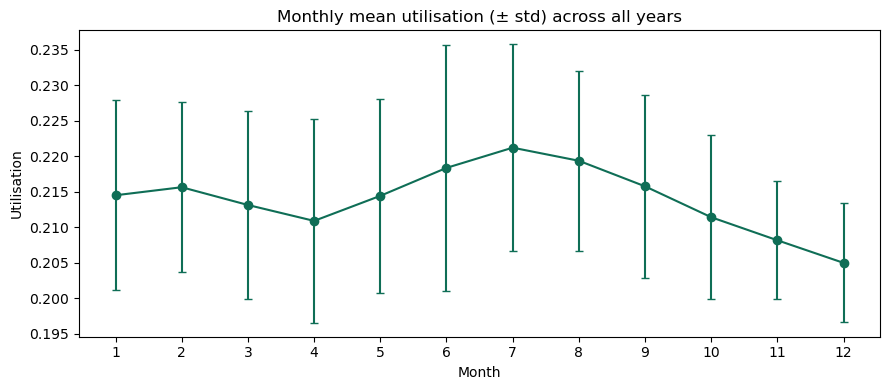

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


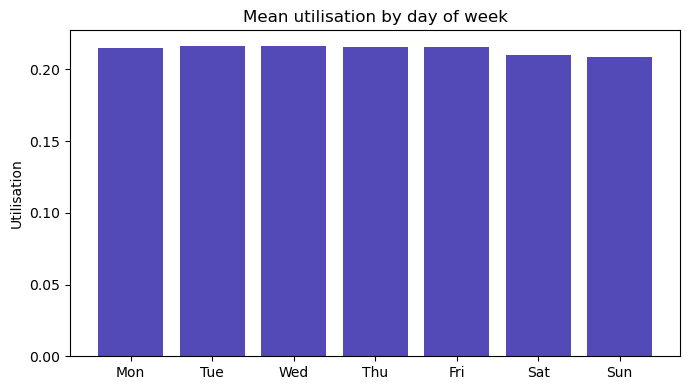

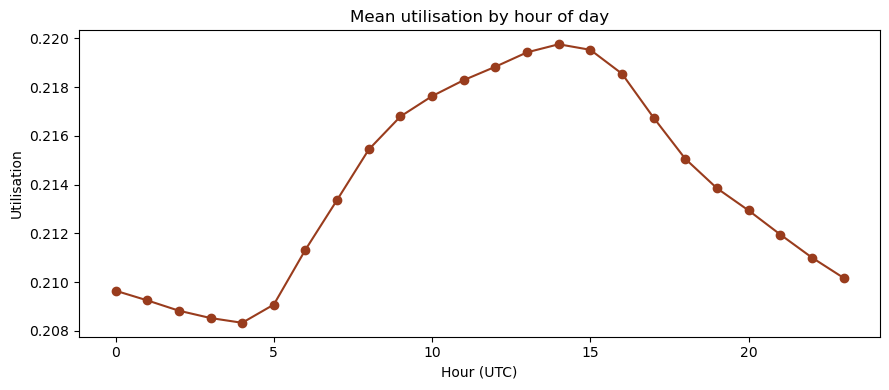

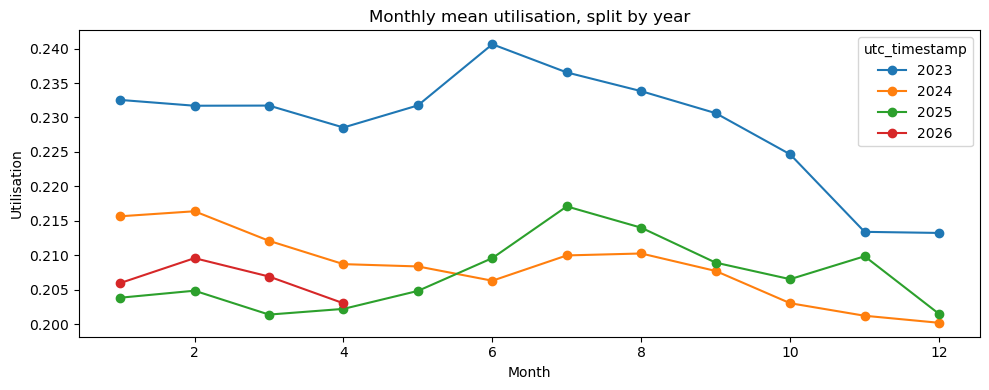

In [75]:
import matplotlib.pyplot as plt

fleet_profile = _get_dc_demand_profile()

monthly_mean = fleet_profile.groupby(fleet_profile.index.month).mean()
monthly_std = fleet_profile.groupby(fleet_profile.index.month).std()

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(monthly_mean.index, monthly_mean.values, yerr=monthly_std.values,
            fmt="-o", color="#0F6E56", capsize=3)
ax.set_xticks(range(1, 13))
ax.set_title("Monthly mean utilisation (± std) across all years")
ax.set_xlabel("Month"); ax.set_ylabel("Utilisation")
plt.tight_layout(); plt.show()

dow_mean = fleet_profile.groupby(fleet_profile.index.dayofweek).mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow_mean.values, color="#534AB7")
ax.set_title("Mean utilisation by day of week")
ax.set_ylabel("Utilisation")
plt.tight_layout(); plt.show()

hourly_mean = fleet_profile.groupby(fleet_profile.index.hour).mean()
fig, ax = plt.subplots(figsize=(9, 4))
hourly_mean.plot(ax=ax, marker="o", color="#993C1D")
ax.set_title("Mean utilisation by hour of day")
ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("Utilisation")
plt.tight_layout(); plt.show()

by_year_month = fleet_profile.groupby([fleet_profile.index.year, fleet_profile.index.month]).mean().unstack(level=0)
fig, ax = plt.subplots(figsize=(10, 4))
by_year_month.plot(ax=ax, marker="o")
ax.set_title("Monthly mean utilisation, split by year")
ax.set_xlabel("Month"); ax.set_ylabel("Utilisation")
plt.tight_layout(); plt.show()

#### **Sticking with the weekly profile due to insignificant changes**

In [76]:
def _build_dc_reference_profile(start="2023-01-01", end="2025-12-31") -> pd.Series:
    '''
    Builds a representative weekly cycle from 3 years of UKPN data,
    averaged by (dayofweek, hour, minute) — the monthly/seasonal component
    was dropped due to insignificant (+/- 1%) seasonal changes.
    
    Current weekly changes are very minor as well. Hopwever, these can be expected to get
    more drastic as the demand increases over the upcoming years.
    Args:
        - start: start of the period (date) taken into account for averaging
        - end: end of the period (date) taken into account for averaging 
    '''
    # get the profile data between start & end
    profile = _get_dc_demand_profile().loc[start:end]
    # profile.index = profile.index.tz_localize(None)
    
    key = pd.MultiIndex.from_arrays([
        profile.index.dayofweek,   # 0=Mon -> 6=Sun
        profile.index.hour,
        profile.index.minute
    ], names=["dayofweek", "hour", "minute"])

    reference_profile = profile.groupby(key).mean()

    return reference_profile

In [77]:
def _get_dc_demand_profile_for_snapshots(snapshots: pd.DatetimeIndex,
                                          reference_profile: pd.Series = None) -> pd.Series:
    '''
    Maps any target snapshots (past or future) onto the cyclical reference profile
    by calendar date/time, so any year's snapshots get a full, gap-free profile.
    '''
    if reference_profile is None:
        reference_profile = _build_dc_reference_profile()

    key = pd.MultiIndex.from_arrays([
        snapshots.dayofweek, snapshots.hour, snapshots.minute
    ], names=["dayofweek", "hour", "minute"])

    values = reference_profile.reindex(key)

    if values.isna().any():
        raise ValueError("Unresolved gaps in weekly reference profile — "
                          "check source data covers all 7 weekdays at every half-hour.")

    return pd.Series(values.values, index=snapshots)

In [78]:
def _get_dc_demand_mw_timeseries(dc_allocation: pd.Series, base_network: pypsa.Network) -> pd.DataFrame:
    
    demand_profile = _get_dc_demand_profile_for_snapshots(base_network.snapshots)

    if demand_profile.isna().any():
        raise ValueError("Unresolved gaps in cyclical DC profile — check reference build.")

    dc_demand_mw = pd.DataFrame(
        {bus: demand_profile.values * cap for bus, cap in dc_allocation[dc_allocation > 0].items()},
        index=base_network.snapshots
    )
    return dc_demand_mw

#### **Add DC as Load**

In [79]:
def add_dc_as_load(base_network: pypsa.Network,
                   buses: list,
                   dc_demand_mw: pd.DataFrame,
                   carrier: str = "Data Centre",
                   logger: Optional[logging.Logger] = None) -> pypsa.Network:
    '''
    Add data centres as simple Load components (no flexibility).

    Args:
        n: PyPSA network
        buses: List of bus names
        dc_demand_mw: Data centre demand time series (MW) with bus columns
        carrier: Carrier name for the loads
        logger: Logger instance

    Returns:
        Network with data centre loads added
    '''
    
    if logger:
        logger.info("Adding data centres as Load components (no flexibility)...")
    
    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)
    
    for bus in buses:
        if bus in dc_demand_mw.columns:
            
            load_name = f"{bus} Data Centre"
            base_network.add("Load",
                             load_name,
                             bus=bus,
                             carrier=carrier,
                             p_set=dc_demand_mw[bus],
                             overwrite=True)

    if logger:
        logger.info(f"Added {len(buses)} data centre loads")

    return base_network

#### **TESTS - adding to network**

In [80]:
ALLOCATION_METHODS = {
    'wind': allocate_north_scotland,
    'current_split_scaled': allocate_current_split_scaled,
    'urban_weighted': allocate_population_density_weighted,
}

n = Q1_zonal
dc_allocation = allocate_population_density_weighted(total_dc_gw=1.9, base_network=n, logger = logging.Logger)
buses = dc_allocation[dc_allocation > 0].index.tolist() # selected buses where dc were added
print(buses)

dc_demand_mw_timeseries = _get_dc_demand_mw_timeseries(dc_allocation=dc_allocation, base_network=n)

n = add_dc_as_load(base_network = n, buses=buses, dc_demand_mw=dc_demand_mw_timeseries)
print(n.generators.head())

print(n.generators[[
    "p_nom_extendable",
    "marginal_cost"
]].head())


6
['Z10', 'Z11', 'Z12', 'Z14', 'Z15', 'Z16']
                                   bus control type  p_nom  p_nom_mod  \
name                                                                    
South_Beach_Wind_Turbine_Somerton  Z12      PQ         1.5        0.0   
Swaffham_1___Ecotech_Wind_Park     Z12      PQ         1.5        0.0   
Mynydd_Gorddu_Wind_Farm            Z13      PQ        10.2        0.0   
Cefn_Croes_Wind_Farm               Z13      PQ        58.5        0.0   
Carno_'B'_Wind_Farm                Z13      PQ        16.8        0.0   

                                   p_nom_extendable  p_nom_min  p_nom_max  \
name                                                                        
South_Beach_Wind_Turbine_Somerton             False        0.0        inf   
Swaffham_1___Ecotech_Wind_Park                False        0.0        inf   
Mynydd_Gorddu_Wind_Farm                       False        0.0        inf   
Cefn_Croes_Wind_Farm                          False       

In [81]:
n.optimize(solver_name="gurobi",)
n.statistics()

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_3286/580858305.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="gurobi",)
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:01<00:00,  4.94it/s]
INFO:linopy.io: Writing time: 10.87s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2834306


INFO:gurobipy:Set parameter LicenseID to value 2834306


...

Solved in 963614 iterations and 93.60 seconds (108.95 work units)


INFO:gurobipy:Solved in 963614 iterations and 93.60 seconds (108.95 work units)


Optimal objective  8.220236373e+09


INFO:gurobipy:Optimal objective  8.220236373e+09


KeyboardInterrupt: 

In [ ]:
n_test = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Jan.nc")

dc_allocation = allocate_population_density_weighted(total_dc_gw=1.9, base_network=n_test, logger=logging.Logger)
buses = dc_allocation[dc_allocation > 0].index.tolist()
dc_demand_mw_timeseries = _get_dc_demand_mw_timeseries(dc_allocation=dc_allocation, base_network=n_test)

n_test = add_dc_as_load(base_network=n_test, buses=buses, dc_demand_mw=dc_demand_mw_timeseries)

status, condition = n_test.optimize(solver_name="gurobi")
print(status, condition)

print("p:", n_test.loads_t.p["cluster_1 Data Centre"].sum())
print("p_set:", n_test.loads_t.p_set["cluster_1 Data Centre"].sum())

INFO:pypsa.network.io:Imported network 'HT35_clustered_kmeans_1_week_Jan (Clustered)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


6


/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_60262/1855981997.py:9: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n_test.optimize(solver_name="gurobi")
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.:  62%|██████▎   | 5/8 [00:18<00:11,  3.72s/it]


OSError: No space left on device (os error 28)

---
---
## <span style=color:aqua> **FLEXIBILITY**
---
---


In [ ]:
# ~~~~~ TEST NETWORKS ~~~~~~~
# Q1_zonal = pypsa.Network("../resources/network/Martas_Q1_zonal_2020_solved.nc")
# Q2_zonal = pypsa.Network("../resources/network/Martas_Q2_zonal_2020_solved.nc")
# Q3_zonal = pypsa.Network("../resources/network/Martas_Q3_zonal_2020_solved.nc")
# Q4_zonal = pypsa.Network("../resources/network/Martas_Q4_zonal_2020_solved.nc")

# Jan_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Jan.nc")
# Nov_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Nov_solved.nc")
# Aug_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Aug_solved.nc")
# Apr_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Apr_solved.nc")

# HT35_flex = pypsa.Network("../resources/network/HT35_flex_solved.nc")

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network 'HT35_clustered_kmeans_1_week_Jan (Clustered)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


### **Demand-Side Management (DSM)**

#### **Adding TEMPORAL & SPATIAL**

In [82]:
def add_dc_temporal_flexibility(base_network: pypsa.Network,
                                  buses: list,
                                  dc_demand_timeseries_mw: pd.DataFrame,
                                  shift_fraction: float = 0.10,
                                  carrier: str = "DSM") -> pd.Series:
    '''
    Function mirroring the 247CFE approach to temporal load shifting of the load.
    '''

    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)
    
    for bus in buses:
        if bus not in dc_demand_timeseries_mw.columns:
            continue
        
        # add the buffer bus which will allow for temporal storage of time delays in and out
        base_network.add("Bus", f"{bus} DSM", carrier=carrier,
                         x=base_network.buses.at[bus, "x"],
                         y=base_network.buses.at[bus, "y"], overwrite=True)
        
        # Store
        base_network.add("Store", f"{bus} DSM",
                         bus=f"{bus} DSM", carrier=carrier,
                         e_cyclic=True, # end state = start state
                         e_nom=1e6, # allowable nominal energy storage = 1M MWh = 1k GWh
                         p_nom_extendable=False, overwrite=True) # fixed, not extendable p_nom capacity / Store's size
        
        # DC -> Buffer (delay IN) & Buffer -> DC (delay OUT) links
        base_network.add("Link", f"{bus} DSM-delayIN", bus0=bus, bus1=f"{bus} DSM", carrier=carrier, 
                         efficiency=1, p_nom=1e6, marginal_cost=1e-5,p_nom_extendable=False,overwrite=True)
        base_network.add("Link", f"{bus} DSM-delayOUT", bus0=f"{bus} DSM", bus1=bus, carrier=carrier, 
                         efficiency=1, p_nom=1e6, marginal_cost=1e-5,p_nom_extendable=False, overwrite=True)

    return base_network

def add_dc_spatial_flexibility(base_network: pypsa.Network,
                               buses: list,
                               carrier: str = "Virtual Link") -> pypsa.Network:
    
    '''
    Similarly to tmeporal flexibility - approach fully based on 247CFE paper.
    '''

    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)

    # vectorised version of the nested for loop from 24/7 CFE paper
    bus_pairs = list(permutations(buses, 2))
    bus0, bus1 = zip(*bus_pairs)
    link_names = [f"VCC {b0}-{b1}" for b0, b1 in bus_pairs]

    base_network.add("Link", link_names,
                     bus0=list(bus0),
                     bus1=list(bus1),
                     carrier=carrier,
                     marginal_cost=1e-5,
                     p_nom=1e6
    )

    return base_network

### **Temporal shifting:** 
**Daily balance = 0 & delay_out-delay_in must be within the flexibility range**

In [ ]:
def temporal_flexibility_constraints(
        buses: list,
        flexibility_fraction: float = 0.10,
        load_name_suffix: str = " Data Centre"):
    '''
    Using the 247CFE approach for constraints etc.

    '''
    delta = flexibility_fraction

    def DSM_constraints(base_network: pypsa.Network, snapshots):
        '''
        Received/sent shifts must sit within the allowable +/- delta range.
        '''
        dsm = base_network.links[base_network.links.carrier == "DSM"]
        
        for bus in buses:
            load_name = f"{bus}{load_name_suffix}"
            if load_name not in base_network.loads_t.p_set.columns:
                continue
            
            delay_in_idx = dsm.query("bus0 == @bus").index
            delay_out_idx = dsm.query("bus1 == @bus").index
            if delay_in_idx.empty or delay_out_idx.empty:
                continue
            
            delay_in = base_network.model["Link-p"].loc[:, delay_in_idx].sum(dims=["name"])
            delay_out = base_network.model["Link-p"].loc[:, delay_out_idx].sum(dims=["name"])

            load = base_network.loads_t.p_set[load_name]
            rhs_upper = load * (1+delta) - load
            rhs_lower = load * (1-delta) - load

            base_network.model.add_constraints(
                delay_out - delay_in <= rhs_upper, name=f"DSM-upper_{bus}"
            )
            base_network.model.add_constraints(
                delay_out - delay_in >= rhs_lower, name=f"DSM-lower_{bus}"
            )

    def DSM_daily_balance(base_network: pypsa.Network):
        '''
        Implementing the temporal flexibility's daily balance = 0.
        '''
        dsm = base_network.links[base_network.links.carrier == "DSM"]

        for bus in buses:
            delay_in_idx = dsm.query("bus0 == @bus").index
            delay_out_idx = dsm.query("bus1 == @bus").index
            if delay_in_idx.empty or delay_out_idx.empty:
                continue

            delay_in = base_network.model["Link-p"].loc[:, delay_in_idx].sum(dims=["name"])
            delay_out = base_network.model["Link-p"].loc[:, delay_out_idx].sum(dims=["name"])

            daily_in = delay_in.groupby("snapshot.dayofyear").sum()
            daily_out = delay_out.groupby("snapshot.dayofyear").sum()

            base_network.model.add_constraints(
                daily_out - daily_in == 0, name=f"DSM-conservation_{bus}"
            )
        
    def extra_functionality(base_network: pypsa.Network, snapshots):
        DSM_constraints(base_network, snapshots)
        DSM_daily_balance(base_network)
        
    return extra_functionality


In [ ]:
NETWORK_PATHS = {
    "Q1_zonal": "../resources/network/Martas_Q1_zonal_2020.nc",
    "Q2_zonal": "../resources/network/Martas_Q2_zonal_2020.nc",
    "Q3_zonal": "../resources/network/Martas_Q3_zonal_2020.nc",
    "Q4_zonal": "../resources/network/Martas_Q4_zonal_2020.nc",
    "Jan_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Jan.nc",
    "Nov_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Nov.nc",
    "Aug_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Aug.nc",
    "Apr_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Apr.nc",
    "HT35_flex": "../resources/network/HT35_flex.nc",
}

def run_test(network_name="Q1_zonal", dc_allocation=1, total_dc_gw=4, temporal_flexibility=0.1):
    if network_name == "Q1_zonal":
        test_network = pypsa.Network(NETWORK_PATHS["Q1_zonal"])
    elif network_name == "Q2_zonal":
        test_network = pypsa.Network(NETWORK_PATHS["Q2_zonal"])
    elif network_name == "Q3_zonal":
        test_network = pypsa.Network(NETWORK_PATHS["Q3_zonal"])
    elif network_name == "Q4_zonal":
        test_network = pypsa.Network(NETWORK_PATHS["Q4_zonal"])
    elif network_name == "Jan_clustered":
        test_network = pypsa.Network(NETWORK_PATHS["Jan_clustered"])
    elif network_name == "Nov_clustered":
        test_network = pypsa.Network(NETWORK_PATHS["Nov_clustered"])
    elif network_name == "Aug_clustered":
        test_network = pypsa.Network(NETWORK_PATHS["Aug_clustered"])
    elif network_name == "Apr_clustered":
        test_network = pypsa.Network(NETWORK_PATHS["Apr_clustered"])
    elif network_name == "HT35_flex":
        test_network = pypsa.Network(NETWORK_PATHS["HT35_flex"])
    else:
        raise ValueError(f"Unknown network_name '{network_name}'. Choose from: {list(NETWORK_PATHS.keys())}")
    
    test_network = test_network.copy()
    
    if dc_allocation == 0:
        dc_allocation = allocate_current_split_scaled(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
    
    elif dc_allocation == 1:
        dc_allocation = allocate_population_density_weighted(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
    
    else:
        dc_allocation = allocate_north_scotland(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
    
    buses = dc_allocation[dc_allocation > 0].index.tolist() # selected buses where dc were added
    print(f"Buses: {buses}")
    dc_demand_timeseries_mw = _get_dc_demand_mw_timeseries(dc_allocation=dc_allocation, base_network=test_network)
    
    test_network = add_dc_as_load(base_network = test_network, buses=buses, dc_demand_mw=dc_demand_timeseries_mw)
    missing = [b for b in buses if b not in test_network.buses.index]
    print("Missing buses:", missing)
    test_network = add_dc_temporal_flexibility(base_network = test_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)
    
    
    dsm_extra_functionality = temporal_flexibility_constraints(buses, flexibility_fraction=temporal_flexibility)
    test_network.optimize(solver_name="gurobi", extra_functionality=dsm_extra_functionality)
    print(test_network.objective)
    print(test_network.generators_t.p.sum().sum())   # is any generation actually happening?
    print(test_network.generators[test_network.generators.marginal_cost > 0].shape)  # do generators have real costs?   
    
    return test_network

In [ ]:
optimised_network = run_test(network_name="Q1_zonal", dc_allocation=1, total_dc_gw=1.9, temporal_flexibility=0.1)
optimised_network.statistics()

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network 'HT35_clustered_kmeans_1_week_Jan (Clustered)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


6
Buses: ['cluster_1', 'cluster_3', 'cluster_4', 'cluster_6', 'cluster_8', 'cluster_9']


cluster_1: max=71.13834100065996, mean=68.02896218308535
cluster_3: max=71.13834100065996, mean=68.02896218308535
cluster_4: max=71.13834100065996, mean=68.02896218308535
cluster_6: max=71.13834100065996, mean=68.02896218308535
cluster_8: max=71.13834100065996, mean=68.02896218308535
cluster_9: max=71.13834100065996, mean=68.02896218308535
Total loads added: 6 / 6
Missing buses: []


/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_1949/574070002.py:57: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  test_network.optimize(solver_name="gurobi", extra_functionality=dsm_extra_functionality)
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 147.55it/s]
INFO:linopy.io: Writing time: 0.65s


Set parameter Username


...

INFO:gurobipy:Solved in 68215 iterations and 5.09 seconds (5.55 work units)


Optimal objective  0.000000000e+00


INFO:gurobipy:Optimal objective  0.000000000e+00
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1290408 primals, 2716938 duals
Objective: 0.00e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance, DSM-upper_cluster_1, DSM-lower_cluster_1, DSM-upper_cluster_3, DSM-lower_cluster_3, DSM-upper_cluster_4, DSM-lower_cluster_4, DSM-upper_cluster_6, DSM-lower_cluster_6, DSM-upper_cluster_8, DSM-lower_cluster_8, DSM-upper_cluster_9, DSM-lower_cluster_

0.0
6303732.328042358
(3783, 48)


Optimal Capacity  \
Generator   Advanced Biofuel                      3.866756e+02   
            Biogas                                1.693847e+03   
            Biomass                               9.536681e+03   
            Combined Cycle Gas Turbine            6.840000e+03   
            Combined Heat & Power                 4.755800e+02   
            European Imports                      2.601500e+04   
            Gas Engine                            4.609000e+02   
            Geothermal                            1.100000e+01   
            Landfill Gas                          8.613264e+02   
            Large Hydro                           1.912848e+03   
            Load Shedding                         8.277345e+04   
            Marine Energy                         3.393580e+02   
            Nuclear                               5.000000e+03   
            Offshore Wind                         8.855320e+04   
            Oil                                   7.850000e+01   
            Onshore Wind                          3.112024e+04   
            Open Cycle Gas Turbine                8.789000e+02   
            Sewage Gas                            5.761304e+01   
            Solar PV                              6.918587e+04   
            Waste to Energy                       4.237504e+03   
Line        AC                                    2.127555e+05   
Link        DC                                    4.150000e+04   
            Data Centre Temporal Flexibility      1.200000e+07   
            Electrolysis                          7.426043e+03   
            H2 Power Generation                   3.918094e+03   
Load        Data Centre                           0.000000e+00   
            Electricity                           0.000000e+00   
StorageUnit Battery Storage                       2.691183e+04   
            Domestic Battery Storage              1.990751e+03   
            Liquid Air Energy Storage             3.857919e+03   
            Pumped Storage Hydroelectricity       6.499878e+03   
Store       Data Centre Temporal Flexibility      6.000000e+06   
            Hydrogen Gas                          6.584211e+05   

                                              Installed Capacity  \
Generator   Advanced Biofuel                        3.866756e+02   
            Biogas                                  1.693847e+03   
            Biomass                                 9.536681e+03   
            Combined Cycle Gas Turbine              6.840000e+03   
            Combined Heat & Power                   4.755800e+02   
            European Imports                        2.601500e+04   
            Gas Engine                              4.609000e+02   
            Geothermal                              1.100000e+01   
            Landfill Gas                            8.613264e+02   
            Large Hydro                             1.912848e+03   
            Load Shedding                           8.277345e+04   
            Marine Energy                           3.393580e+02   
            Nuclear                                 5.000000e+03   
            Offshore Wind                           8.855320e+04   
            Oil                                     7.850000e+01   
            Onshore Wind                            3.112024e+04   
            Open Cycle Gas Turbine                  8.789000e+02   
            Sewage Gas                              5.761304e+01   
            Solar PV                                6.918587e+04   
            Waste to Energy                         4.237504e+03   
Line        AC                                      2.127555e+05   
Link        DC                                      4.150000e+04   
            Data Centre Temporal Flexibility        1.200000e+07   
            Electrolysis                            7.426043e+03   
            H2 Power Generation                     3.918094e+03   
Load        Data Centre          

In [ ]:
import pypsa-gb

map_n = prepare_map_network(optimised_network)
map_n.buses["capacity_GW"] = bus_capacity.reindex(map_n.buses.index).fillna(0)

print("Generation Capacity Distribution (Bus size = capacity)")
print("lon range:", float(map_n.buses.x.min()), float(map_n.buses.x.max()))
print("lat range:", float(map_n.buses.y.min()), float(map_n.buses.y.max()))

# Interactive network map with capacity-based bus sizing
m = map_n.plot.explore(
    map_style="light",
    tooltip=True,
    bus_size=map_n.buses["capacity_GW"].clip(lower=0.1) * 1000,
    bus_size_factor=0.05,
    branch_width_factor=1.0,
    bus_columns=["capacity_GW", "v_nom"],
)
m

SyntaxError: invalid syntax (2546470864.py, line 1)

In [103]:
def virtual_link_constraints(base_network: pypsa.Network,
                             snapshots,
                             buses: list,
                             flexibility_fraction: float = 0.10,
                             load_name_suffix: str = " Data Centre",
                             carrier: str = "Virtual Link"):

    delta = flexibility_fraction
    vls = base_network.links[base_network.links.carrier == carrier]

    for bus in buses:
        load_name = f"{bus}{load_name_suffix}"
        if load_name not in base_network.loads_t.p_set.columns:
             continue
        sent_idx = vls.query("bus0==@bus").index
        received_idx = vls.query("bus1==@bus").index

        if sent_idx.empty and received_idx.empty:
             continue
        
        sent = base_network.model["Link-p"].loc[:, sent_idx].sum(dims=["Link"]) if not sent_idx.empty else 0
        received = base_network.model["Link-p"].loc[:, received_idx].sum(dims=["Link"]) if not received_idx.empty else 0
        load = base_network.loads_t.p_set[load_name]

        rhs_upper = load * (1+delta) - load
        rhs_lower = load * (1-delta) - load

        base_network.model.add_constraints(received-sent <= rhs_upper, name=f"vl_limit-upper_{bus}")
        base_network.model.add_constraints(received-sent >= rhs_lower, name=f"vl_limit-lower_{bus}")

def revert_links(base_network: pypsa.Network,
                  flex_carriers: list = ["Virtual Link", "DSM"]) -> None:
    '''
    Sets sign=-1 for flexibility links (virtual_link, dsm) so nodal balance
    treats bus0->bus1 flow consistently with the CFE/vl_constraints direction
    convention. All other links keep sign=1.
    '''
    is_flex = base_network.links.carrier.isin(flex_carriers)
    base_network.links.loc[is_flex, "sign"] = -1
    base_network.links.loc[~is_flex, "sign"] = 1
     
     

def temporal_plus_spatial_constraints(base_network: pypsa.Network,
                             buses: list,
                             flexibility_fraction: float = 0.10,
                             load_name_suffix: str = " Data Centre",
                             vl_carrier: str = "Virtual Link",
                             dsm_carrier: str = "DSM"):

    delta = flexibility_fraction
    vls = base_network.links[base_network.links.carrier == vl_carrier]
    dsm = base_network.links[base_network.links.carrier == dsm_carrier]

    for bus in buses:
        load_name = f"{bus}{load_name_suffix}"
        if load_name not in base_network.loads_t.p_set.columns:
            continue

        sent_idx = vls.query("bus0==@bus").index
        received_idx = vls.query("bus1==@bus").index
        delay_in_idx = dsm.query("bus0==@bus").index
        delay_out_idx = dsm.query("bus1==@bus").index
        
        if sent_idx.empty and received_idx.empty:
            continue    
            
        sent = base_network.model["Link-p"].loc[:, sent_idx].sum(dims=["Link"]) if not sent_idx.empty else 0
        received = base_network.model["Link-p"].loc[:, received_idx].sum(dims=["Link"]) if not received_idx.empty else 0
        delay_in = base_network.model["Link-p"].loc[:,delay_in_idx].sum(dims=["Link"]) if not delay_in_idx.empty else 0
        delay_out = base_network.model["Link-p"].loc[:,delay_out_idx].sum(dims=["Link"]) if not delay_out_idx.empty else 0

        load = base_network.loads_t.p_set[load_name]
        rhs_upper = load * (1+delta) - load
        rhs_lower = load * (1-delta) - load

        combined = (received-sent) + (delay_out-delay_in)

        base_network.model.add_constraints(combined<=rhs_upper, name=f"LoadShift-upper_{bus}")
        base_network.model.add_constraints(combined>=rhs_lower, name=f"LoadShift-lower_{bus}")


# def cfe_constraint(base_network):
     

# def cfe_constraints(n):
        # weights = n.snapshot_weightings["generators"]
        # delta = float(flexibility) / 100
        # vls = n.links[n.links.carrier == "virtual_link"]
        # dsm = n.links[n.links.carrier == "dsm"]
        # # vls = n.generators[n.generators.carrier=='virtual_link']

        # for location, name in datacenters.items():
        #     # LHS
        #     clean_gens = [name + " " + g for g in clean_techs]
        #     storage_dischargers = [name + " " + g for g in storage_discharge_techs]
        #     storage_chargers = [name + " " + g for g in storage_charge_techs]

        #     gen_sum = (n.model["Generator-p"].loc[:, clean_gens] * weights).sum()
        #     discharge_sum = (
        #         n.model["Link-p"].loc[:, storage_dischargers]
        #         * n.links.loc[storage_dischargers, "efficiency"]
        #         * weights
        #     ).sum()
        #     charge_sum = (
        #         -1 * (n.model["Link-p"].loc[:, storage_chargers] * weights).sum()
        #     )

        #     ci_export = n.model["Link-p"].loc[:, [name + " export"]]
        #     ci_import = n.model["Link-p"].loc[:, [name + " import"]]
        #     grid_sum = (
        #         (-1 * ci_export * weights)
        #         + (
        #             ci_import
        #             * n.links.at[name + " import", "efficiency"]
        #             * grid_supply_cfe
        #             * weights
        #         )
        #     ).sum()  # linear expr

        #     lhs = gen_sum + discharge_sum + charge_sum + grid_sum

        #     # RHS
        #     total_load = (n.loads_t.p_set[name + " load"] * weights).sum()

        #     vls_snd = vls.query("bus0==@name").index
        #     vls_rec = vls.query("bus1==@name").index
        #     total_snd = (
        #         n.model["Link-p"].loc[:, vls_snd] * weights
        #     ).sum()  # NB sum over both axes
        #     total_rec = (n.model["Link-p"].loc[:, vls_rec] * weights).sum()

        #     dsm_delayin = dsm.query("bus0==@name").index
        #     dsm_delayout = dsm.query("bus1==@name").index
        #     total_delayin = (
        #         n.model["Link-p"].loc[:, dsm_delayin] * weights
        #     ).sum()  # NB sum over both axes
        #     total_delayout = (n.model["Link-p"].loc[:, dsm_delayout] * weights).sum()

        #     flex = penetration * (
        #         total_rec - total_snd + total_delayout - total_delayin
        #     )

        #     n.model.add_constraints(
        #         lhs - flex >= penetration * (total_load), name=f"CFE_constraint_{name}"
        #     )    

In [110]:
NETWORK_PATHS = {
    "Q1_zonal": "../resources/network/Martas_Q1_zonal_2020.nc",
    "Q2_zonal": "../resources/network/Martas_Q2_zonal_2020.nc",
    "Q3_zonal": "../resources/network/Martas_Q3_zonal_2020.nc",
    "Q4_zonal": "../resources/network/Martas_Q4_zonal_2020.nc",
    "Jan_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Jan.nc",
    "Nov_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Nov.nc",
    "Aug_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Aug.nc",
    "Apr_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Apr.nc",
    "HT35_flex": "../resources/network/HT35_flex.nc",
}

def run_flexibility_test(network_name="Q1_zonal", dc_allocation=1, total_dc_gw=4,
             flexibility_fraction=0.1, mode="temporal"):
    '''
    mode: "temporal", "spatial", or "both" — controls which flexibility
    mechanism(s) are built and which extra_functionality is used.
    '''
    if network_name not in NETWORK_PATHS:
        raise ValueError(f"Unknown network_name '{network_name}'. Choose from: {list(NETWORK_PATHS.keys())}")
    test_network = pypsa.Network(NETWORK_PATHS[network_name]).copy()

    reference = _build_dc_reference_profile()
    key = pd.MultiIndex.from_arrays(
        [test_network.snapshots.dayofweek, test_network.snapshots.hour, test_network.snapshots.minute],
        names=["dayofweek", "hour", "minute"]
    )
    missing_keys = key[~key.isin(reference.index)]
    print(missing_keys.unique())
    
    if dc_allocation == 0:
        dc_allocation = allocate_current_split_scaled(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
    
    elif dc_allocation == 1:
        dc_allocation = allocate_population_density_weighted(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
    
    else:
        dc_allocation = allocate_north_scotland(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)

    buses = dc_allocation[dc_allocation > 0].index.tolist() # selected buses where dc were added
    print(f"Buses: {buses}")
    dc_demand_timeseries_mw = _get_dc_demand_mw_timeseries(dc_allocation=dc_allocation, base_network=test_network)
    
    test_network = add_dc_as_load(base_network = test_network, buses=buses, dc_demand_mw=dc_demand_timeseries_mw)
    missing = [b for b in buses if b not in test_network.buses.index]
    print("Missing buses:", missing)
    flexible_network = test_network.copy()
    test_network.optimize(solver_name="gurobi")
    

    if mode == "temporal":
        flexible_network = add_dc_temporal_flexibility(base_network = flexible_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)
        dsm_extra_functionality = temporal_flexibility_constraints(buses, flexibility_fraction=flexibility_fraction)
        flexible_network.optimize(solver_name="gurobi", extra_functionality=dsm_extra_functionality)

    elif mode == "spatial":
        flexible_network = add_dc_spatial_flexibility(base_network = flexible_network, buses=buses)
        vl_extra_functionality = virtual_link_constraints(buses, flexibility_fraction=flexibility_fraction)
        flexible_network.optimize(solver_name="gurobi", extra_functionality=vl_extra_functionality)

    elif mode == "both":
        flexible_network = add_dc_spatial_flexibility(base_network = flexible_network, buses=buses)
        flexible_network = add_dc_temporal_flexibility(base_network = flexible_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)

        revert_links(flexible_network)
        def extra_functionality(base_network, snapshots):
            temporal_flexibility_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)
            virtual_link_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)

        flexible_network.optimize(solver_name="gurobi", extra_functionality=extra_functionality)
    else:
        print("Inflexible Data Centre mode")

  
    print(test_network.objective)
    print(test_network.generators_t.p.sum().sum())   # is any generation actually happening?
    print(test_network.generators[test_network.generators.marginal_cost > 0].shape)  # do generators have real costs?   
    
    return test_network, flexible_network

In [111]:
run_flexibility_test(network_name="Q1_zonal", dc_allocation=1, total_dc_gw=4,
             flexibility_fraction=0.1, mode="temporal")

INFO:pypsa.network.io:Imported network 'Martas_Q1_zonal_2020 (Full)' has buses, carriers, generators, links, loads, storage_units


AssertionError: Length of new_levels (4) must be <= self.nlevels (3)

NameError: name 'test_network' is not defined

### **247 CFE**


In [ ]:
def add_vl(n, names: List[str]) -> None:
    """
    Add virtual links connecting data centers across physical network.

    Args:
    - n: The network to add virtual links to.
    - names: A list of data center names.

    Returns:
    - None
    """
    # Complete graph: n * (n - 1) / 2 edges
    for i in range(len(names)):
        for j in range(len(names)):
            if i != j:  # Exclude the case of the same datacenter
                link_name = f"vcc_{names[i]}_{names[j]}"
                n.add(
                    "Link",
                    link_name,
                    bus0=names[i],
                    bus1=names[j],
                    carrier="virtual_link",
                    marginal_cost=1e-5,  # large enough to avoid optimization artifacts, small enough not to influence PPA portfolio
                    p_nom=1e6,
                )


def add_shifters(n) -> None:
    """
    Alternative form of virtual links connecting data centers across physical network

    Args:
    - n: The network to which the virtual links will be added

    Returns:
    - None
    """
    for i in range(len(names)):
        gen_name = f"vl_{names[i]}"
        n.add(
            "Generator",
            gen_name,
            bus=names[i],
            carrier="virtual_link",
            p_nom=40,
            marginal_cost=0.001,
            p_min_pu=-1,
            p_max_pu=1,
        )


def add_dsm(n) -> None:
    """
    Add option to shift loads over time, aka temporal DSM

    Args:
    - n: The network object to which the DSM components will be added

    Returns:
    - None
    """
    for location, name in datacenters.items():
        n.add("Bus", f"{name} DSM", carrier="dsm")

        n.add(
            "Store",
            f"{name} DSM",
            bus=f"{name} DSM",
            carrier="dsm",
            e_cyclic=True,
            e_nom=1e6,
            p_nom_extendable=False,
        )

        n.add(
            "Link",
            f"{name} DSM-delayin",
            bus0=name,
            bus1=f"{name} DSM",
            carrier="dsm",
            efficiency=1,
            p_nom=1e6,
            marginal_cost=1e-5,
            p_nom_extendable=False,
        )

        n.add(
            "Link",
            f"{name} DSM-delayout",
            bus0=f"{name} DSM",
            bus1=name,
            carrier="dsm",
            efficiency=1,
            p_nom=1e6,
            marginal_cost=1e-5,
            p_nom_extendable=False,
        )

NameError: name 'List' is not defined

---
---
### <span style=color:orange>   **ACTUAL PyPSA-GB IMPLEMENTATION**
---
---

In [ ]:
"""
Data Centre Demand Disaggregation and Flexibility

This script disaggregates data centre electricity demand from the total demand
and optionally adds flexibility modelling.

================================================================================
SPACE HEATING FLEXIBILITY MECHANISMS
================================================================================

Both TANK and COSY modes are mechanisms for providing SPACE HEATING flexibility.
They represent different physical storage mechanisms for pre-heating:

TANK Mode (Hot Water Tank Storage):
    - Uses hot water cylinder/tank as thermal energy storage
    - Heat pump pre-heats water stored in tank during low-cost periods
    - Tank releases heat to space heating system when needed
    - Physical component: Hot water cylinder (e.g., 200-500L tank)
    - Typical storage capacity: 10-50 kWh thermal
    - Heat loss: ~1-3% per hour depending on insulation
    - PyPSA components created:
        * Bus: thermal bus for heat flow
        * Store: hot water tank (energy storage in kWh)
        * Link: heat pump (converts electricity to heat at COP efficiency)
        * Load: space heating demand at thermal bus

COSY Mode (Building Thermal Inertia):
    - Uses building thermal mass (walls, floors, furniture) as storage
    - Heat pump pre-heats building fabric during low-cost periods  
    - Building slowly releases stored heat, maintaining comfort
    - Physical component: Building fabric itself (concrete, brick, etc.)
    - Typical storage capacity: 2-10 kWh thermal per 100m² floor area
    - Heat loss: Depends on building insulation (EPC rating)
    - PyPSA components created:
        * Bus: thermal inertia bus for heat flow
        * Store: building thermal mass (energy storage in kWh)
        * Link: heat pump (converts electricity to heat at COP efficiency)
        * Load: space heating demand at thermal bus

Key Equations (same for both modes):
    thermal_demand_mw = electric_demand_mw * COP
    
    Where COP (Coefficient of Performance) is temperature-dependent:
    - Higher COP in milder weather (COP ~4-5 at 10°C ambient)
    - Lower COP in cold weather (COP ~2-3 at 0°C ambient)

Configuration (config/defaults.yaml):
    heat_pumps:
      enabled: true
      flexibility:
        enabled: true
        tank_share: 0.5    # 50% of HP demand uses TANK mechanism
        cosy_share: 0.5    # 50% of HP demand uses COSY mechanism
        # Note: tank_share + cosy_share should equal 1.0

Without flexibility enabled, data centres are modeled as simple Load components
with fixed electricity demand profiles (no shifting capability).
================================================================================
"""

import pandas as pd
import pypsa
import logging
import numpy as np
import xarray as xr
from pathlib import Path
import sys
from typing import Optional, Dict, Any

# Add parent directory to path for imports
sys.path.insert(0, str(Path(__file__).parent.parent))
from scripts.utilities.logging_config import setup_logging
from scripts.utilities.network_io import load_network
from scripts.demand.load import load_spatial_mapping_data, aggregate_demand_to_network_topology

# ──────────────────────────────────────────────────────────────────────────────
#                       Spatial Allocation Functions
# ──────────────────────────────────────────────────────────────────────────────

def allocate_north(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:

    '''
    Allocate data centres where the most reliable renewable energy is in the UK - wind.
    '''
    logger.info("Allocating all data centres in Northern Scotland")
    load_demand = 
    return dc_allocation


def allocate_proportional(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:
    """
    Allocate data centre demand proportionally to existing base demand.

    This assumes heat pump adoption correlates with overall electricity consumption.
    """
    logger.info("Allocating proportionally to base demand")

    # Get base demand per load (column names are load indices, not bus names)
    if len(base_network.loads_t.p_set) > 0:
        load_demand = base_network.loads_t.p_set.sum(axis=0)  # Sum over time
    else:
        logger.warning("No time-varying loads found, using static p_set")
        load_demand = base_network.loads.p_set

    # Map load demand to buses (aggregate by bus)
    load_to_bus = base_network.loads["bus"]
    valid_loads = [l for l in load_demand.index if l in load_to_bus.index]
    if not valid_loads:
        logger.error("No valid loads found for proportional allocation")
        raise ValueError("No valid loads for allocation")

    load_demand = load_demand.loc[valid_loads]
    bus_mapping = load_to_bus.loc[valid_loads]
    bus_demand = load_demand.groupby(bus_mapping).sum()

    # Calculate fractions
    total_base = bus_demand.sum()
    if total_base == 0:
        logger.error("Total base demand is zero - cannot allocate proportionally")
        raise ValueError("Zero base demand")

    bus_fractions = bus_demand / total_base
    dc_allocation = bus_fractions * total_gwh

    logger.info(f"Allocated {dc_allocation.sum():.1f} GWh across {len(dc_allocation)} buses")
    logger.info(f"Min: {dc_allocation.min():.3f} GWh, Max: {dc_allocation.max():.3f} GWh")

    return dc_allocation


def allocate_uniform(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:
    """
    Allocate data centre demand uniformly across all buses.
    
    This assumes uniform heat pump adoption regardless of location.
    """
    logger.info("Allocating uniformly across all buses")
    
    n_buses = len(base_network.buses)
    dc_per_bus = total_gwh / n_buses
    dc_allocation = pd.Series(dc_per_bus, index=base_network.buses.index)
    
    logger.info(f"Allocated {dc_allocation.sum():.1f} GWh uniformly ({dc_per_bus:.3f} GWh per bus)")
    
    return dc_allocation


def allocate_urban_weighted(total_gwh: float, base_network: pypsa.Network, logger,
                            urban_weight: float = 1.5) -> pd.Series:
    """
    Allocate heat pump demand weighted towards urban areas (high demand buses).

    Uses a power function to weight allocation towards higher-demand areas.
    """
    logger.info("Allocating with urban weighting")

    # Get base demand per load
    if len(base_network.loads_t.p_set) > 0:
        load_demand = base_network.loads_t.p_set.sum(axis=0)
    else:
        load_demand = base_network.loads.p_set

    # Map load demand to buses (aggregate by bus)
    load_to_bus = base_network.loads["bus"]
    valid_loads = [l for l in load_demand.index if l in load_to_bus.index]
    if not valid_loads:
        logger.warning("No valid loads for urban weighting, falling back to proportional")
        return allocate_proportional(total_gwh, base_network, logger)

    load_demand = load_demand.loc[valid_loads]
    bus_mapping = load_to_bus.loc[valid_loads]
    bus_demand = load_demand.groupby(bus_mapping).sum()

    # Apply power weighting (exponent > 1 favors high-demand areas)
    weighted_demand = bus_demand ** urban_weight

    total_weighted = weighted_demand.sum()
    if total_weighted == 0:
        logger.warning("Weighted demand is zero, falling back to proportional")
        return allocate_proportional(total_gwh, base_network, logger)

    bus_fractions = weighted_demand / total_weighted
    hp_allocation = bus_fractions * total_gwh

    logger.info(f"Allocated {hp_allocation.sum():.1f} GWh with urban weighting (exponent={urban_weight})")

    return hp_allocation


# Allocation method registry
ALLOCATION_METHODS = {
    '': allocate_north,
    'uniform': allocate_uniform,
    'urban_weighted': allocate_urban_weighted,
}


def _get_timestep_hours(index: pd.DatetimeIndex, default: float = 1.0) -> float:
    if index is None or len(index) < 2:
        return default
    delta_hours = (index[1] - index[0]).total_seconds() / 3600.0
    return delta_hours if delta_hours > 0 else default


def _get_cop_series(cop_profile: pd.DataFrame,
                    bus: str,
                    snapshots: pd.DatetimeIndex,
                    logger: Optional[logging.Logger] = None) -> pd.Series:
    if cop_profile is None or cop_profile.empty:
        raise ValueError("COP profile is required for heat pump flexibility")

    if bus in cop_profile.columns:
        cop_series = cop_profile[bus]
    elif cop_profile.shape[1] == 1:
        cop_series = cop_profile.iloc[:, 0]
    else:
        raise ValueError(f"No COP series available for bus '{bus}'")

    if snapshots is not None and not cop_series.index.equals(snapshots):
        cop_series = cop_series.reindex(snapshots)
        cop_series = cop_series.interpolate(method="time")

    if cop_series.isna().any():
        raise ValueError(f"COP series has missing values for bus '{bus}'")

    return cop_series


def _bus_coords_kwargs(network: pypsa.Network, source_bus: str) -> Dict[str, float]:
    if source_bus in network.buses.index and {'x', 'y'}.issubset(network.buses.columns):
        return {
            'x': float(network.buses.at[source_bus, 'x']),
            'y': float(network.buses.at[source_bus, 'y']),
        }
    return {}


def _get_fes_scenario_column(df: pd.DataFrame) -> Optional[str]:
    for col in ['FES Pathway', 'FES Scenario', '\ufeffFES Scenario', 'ï»¿FES Scenario']:
        if col in df.columns:
            return col
    return None


def _calculate_fes_fraction(fes_path: str,
                            fes_scenario: str,
                            modelled_year: int,
                            component_blocks: list,
                            logger: logging.Logger) -> Optional[float]:
    if not fes_path or not Path(fes_path).exists():
        return None

    try:
        fes = pd.read_csv(fes_path, low_memory=False)
    except Exception as exc:
        logger.warning(f"Failed to read FES data: {exc}")
        return None

    scenario_col = _get_fes_scenario_column(fes)
    if scenario_col is None or 'Building Block ID Number' not in fes.columns:
        return None

    year_col = str(modelled_year)
    if year_col not in fes.columns:
        return None

    total = fes[
        (fes['Building Block ID Number'] == 'Dem_BB003') &
        (fes[scenario_col] == fes_scenario)
    ]
    comp = fes[
        (fes['Building Block ID Number'].isin(component_blocks)) &
        (fes[scenario_col] == fes_scenario)
    ]

    total_val = pd.to_numeric(total[year_col], errors='coerce').sum()
    comp_val = pd.to_numeric(comp[year_col], errors='coerce').sum()

    if total_val <= 0:
        return None
    return comp_val / total_val


def _load_fes_component_gsp_demand(
    fes_path: str,
    fes_scenario: str,
    modelled_year: int,
    component_blocks: list,
    logger: logging.Logger
) -> Optional[pd.Series]:
    if isinstance(fes_path, list):
        fes_path = fes_path[0] if fes_path else None

    if not fes_path or not Path(fes_path).exists():
        return None

    try:
        fes = pd.read_csv(fes_path, low_memory=False)
    except Exception as exc:
        logger.warning(f"Failed to read FES data: {exc}")
        return None

    scenario_col = _get_fes_scenario_column(fes)
    if scenario_col is None or 'Building Block ID Number' not in fes.columns:
        return None

    year_col = str(modelled_year)
    if year_col not in fes.columns or 'GSP' not in fes.columns:
        return None

    filtered = fes[
        (fes['Building Block ID Number'].isin(component_blocks)) &
        (fes[scenario_col] == fes_scenario)
    ].copy()

    if filtered.empty:
        return None

    filtered = filtered[filtered['GSP'].notna()]
    filtered['GSP'] = filtered['GSP'].astype(str).str.strip()
    filtered['_value'] = pd.to_numeric(filtered[year_col], errors='coerce')

    gsp_demand = filtered.groupby('GSP')['_value'].sum().dropna()
    gsp_demand = gsp_demand[gsp_demand > 0]

    if gsp_demand.empty:
        return None

    logger.info(f"Loaded FES GSP demand for {len(gsp_demand)} GSPs (total {gsp_demand.sum():.1f} GWh)")
    return gsp_demand


def _allocate_using_fes_gsp(
    total_gwh: float,
    base_network: pypsa.Network,
    component_profile: pd.DataFrame,
    fes_path: str,
    fes_scenario: str,
    modelled_year: int,
    network_model: str,
    fes_year: Optional[int],
    component_blocks: list,
    logger: logging.Logger
) -> Optional[pd.Series]:
    if not fes_scenario:
        return None

    gsp_demand = _load_fes_component_gsp_demand(
        fes_path, fes_scenario, modelled_year, component_blocks, logger
    )
    if gsp_demand is None:
        return None

    total_fes = gsp_demand.sum()
    if total_fes <= 0:
        return None

    scaled_gsp = gsp_demand * (total_gwh / total_fes)
    weights = scaled_gsp / scaled_gsp.sum()

    profile_series = component_profile.iloc[:, 0]
    gsp_timeseries = pd.DataFrame(
        {gsp: profile_series * weight for gsp, weight in weights.items()},
        index=component_profile.index
    )

    fes_demand = scaled_gsp.to_frame(name='demand_gwh')
    if isinstance(network_model, list):
        network_model = network_model[0] if network_model else "ETYS"
    if not network_model:
        network_model = "ETYS"
    if isinstance(fes_year, list):
        fes_year = fes_year[0] if fes_year else None
    mapping_year = int(fes_year) if fes_year else 2024
    spatial_mapping = load_spatial_mapping_data(
        network_model, list(fes_demand.index), mapping_year, logger
    )

    aggregated_demand, _ = aggregate_demand_to_network_topology(
        fes_demand,
        gsp_timeseries,
        network_model,
        base_network,
        spatial_mapping,
        logger,
        is_historical=False
    )

    allocation = aggregated_demand.iloc[:, 0]
    allocation = allocation.reindex(base_network.buses.index, fill_value=0.0)
    logger.info(
        f"Allocated {allocation.sum():.1f} GWh across {len(allocation)} buses using FES GSP distribution"
    )
    return allocation

# ──────────────────────────────────────────────────────────────────────────────
# Heat Pump Flexibility Functions
# ──────────────────────────────────────────────────────────────────────────────

def add_hp_as_load(n: pypsa.Network,
                   buses: list,
                   hp_demand_mw: pd.DataFrame,
                   carrier: str = "heat pump",
                   logger: Optional[logging.Logger] = None) -> pypsa.Network:
    """
    Add heat pumps as simple Load components (no flexibility).

    Args:
        n: PyPSA network
        buses: List of bus names
        hp_demand_mw: Heat pump demand time series (MW) with bus columns
        carrier: Carrier name for the loads
        logger: Logger instance

    Returns:
        Network with heat pump loads added
    """
    if logger:
        logger.info("Adding heat pumps as Load components (no flexibility)...")

    for bus in buses:
        if bus in hp_demand_mw.columns:
            load_name = f"{bus} heat pump"
            n.add("Load",
                  load_name,
                  bus=bus,
                  carrier=carrier,
                  p_set=hp_demand_mw[bus])

    if logger:
        logger.info(f"Added {len(buses)} heat pump loads")

    return n


def add_hp_tank_flexibility(n: pypsa.Network,
                            buses: list,
                            hp_demand_mw: pd.DataFrame,
                            cop_profile: pd.DataFrame,
                            config: Dict[str, Any],
                            logger: Optional[logging.Logger] = None,
                            name_suffix: Optional[str] = None) -> pypsa.Network:
    """
    Add heat pump flexibility using hot water tank storage (TANK mode).

    Creates PyPSA components:
    - Bus: thermal bus for hot water
    - Store: hot water tank (thermal energy storage)
    - Link: heat pump (electricity -> thermal with COP efficiency)
    - Load: hot water demand (fixed profile)

    Args:
        n: PyPSA network
        buses: List of electric bus names
        hp_demand_mw: Heat pump demand time series (MW)
        cop_profile: COP time series for heat pumps
        config: Flexibility configuration dict with tank parameters
        logger: Logger instance

    Returns:
        Network with tank flexibility components added
    """
    if logger:
        logger.info("Adding heat pump TANK flexibility...")

    timestep_hours = _get_timestep_hours(hp_demand_mw.index)
    tank_config = config.get('tank', {})
    volume_liters = tank_config.get('volume_liters', 200)
    temp_range = tank_config.get('temp_range', [50, 65])
    standing_loss = tank_config.get('standing_loss_per_hour', 0.01)
    heater_power_kw = tank_config.get('heater_power_kw', 3.0)

    # Calculate tank energy capacity
    # E = m * c * dT, where c = 4.186 kJ/(kg·K), 1 kWh = 3600 kJ
    temp_diff = temp_range[1] - temp_range[0]  # °C
    # 1 liter water = 1 kg, specific heat = 4.186 kJ/(kg·K)
    tank_capacity_kwh = volume_liters * 4.186 * temp_diff / 3600

    if logger:
        logger.info(f"Tank parameters: {volume_liters}L, {temp_range[0]}-{temp_range[1]}°C")
        logger.info(f"Tank capacity: {tank_capacity_kwh:.2f} kWh thermal")
        logger.info(f"Standing loss: {standing_loss*100:.1f}%/hour")

    suffix = f" {name_suffix}" if name_suffix else ""

    buses = [bus for bus in buses if bus in hp_demand_mw.columns]
    if buses:
        demand_totals = hp_demand_mw[buses].sum()
        buses = demand_totals[demand_totals > 0].index.tolist()

    if not buses:
        if logger:
            logger.info("No nonzero heat pump demand for TANK flexibility")
        return n

    thermal_bus_names = []
    thermal_bus_x = []
    thermal_bus_y = []
    store_names = []
    store_buses = []
    store_e_nom = []

    link_names = []
    link_bus0 = []
    link_bus1 = []
    link_p_nom = []
    link_eff = {}

    load_names = []
    load_buses = []
    load_p_set = {}

    for bus in buses:
        thermal_bus = f"{bus} heat"
        tank_name = f"{bus} hot water tank{suffix}"
        hp_link_name = f"{bus} heat pump{suffix}"
        hw_load_name = f"{bus} hot water demand{suffix}"

        if thermal_bus not in n.buses.index:
            thermal_bus_names.append(thermal_bus)
            coords = _bus_coords_kwargs(n, bus)
            if coords:
                thermal_bus_x.append(coords["x"])
                thermal_bus_y.append(coords["y"])

        cop_series = _get_cop_series(cop_profile, bus, n.snapshots, logger)
        electric_demand = hp_demand_mw[bus]
        if not electric_demand.index.equals(n.snapshots):
            electric_demand = electric_demand.reindex(n.snapshots)
            electric_demand = electric_demand.interpolate(method="time")
        if electric_demand.isna().any():
            raise ValueError(f"Heat pump demand has missing values for bus '{bus}'")

        thermal_demand_mw = electric_demand * cop_series
        peak_thermal_mw = thermal_demand_mw.max()
        peak_electric_mw = electric_demand.max()

        # Estimate number of dwellings from peak thermal demand
        peak_thermal_kw_per_dwelling = config.get('peak_thermal_kw_per_dwelling', 10.0)
        n_dwellings = max(1, int(peak_thermal_mw * 1000 / peak_thermal_kw_per_dwelling))
        total_tank_mwh = n_dwellings * tank_capacity_kwh / 1000

        store_names.append(tank_name)
        store_buses.append(thermal_bus)
        store_e_nom.append(total_tank_mwh)

        link_names.append(hp_link_name)
        link_bus0.append(bus)
        link_bus1.append(thermal_bus)
        # Size link to meet peak demand with margin for pre-heating flexibility
        link_sizing_margin = config.get('link_sizing_margin', 1.5)
        link_p_nom.append(peak_electric_mw * link_sizing_margin)
        link_eff[hp_link_name] = cop_series

        load_names.append(hw_load_name)
        load_buses.append(thermal_bus)
        load_p_set[hw_load_name] = thermal_demand_mw

    if thermal_bus_names:
        bus_kwargs = {"carrier": "heat"}
        if len(thermal_bus_x) == len(thermal_bus_names):
            bus_kwargs["x"] = thermal_bus_x
            bus_kwargs["y"] = thermal_bus_y
        n.add("Bus", thermal_bus_names, **bus_kwargs)

    if store_names:
        n.add(
            "Store",
            store_names,
            bus=store_buses,
            carrier="hot water",
            e_nom=store_e_nom,
            e_nom_extendable=False,
            e_cyclic=True,
            standing_loss=standing_loss,
        )

    if link_names:
        eff_df = pd.DataFrame(link_eff, index=n.snapshots)[link_names]
        n.add(
            "Link",
            link_names,
            bus0=link_bus0,
            bus1=link_bus1,
            carrier="heat pump",
            efficiency=eff_df,
            p_nom=link_p_nom,
            p_nom_extendable=False,
        )

    if load_names:
        load_df = pd.DataFrame(load_p_set, index=n.snapshots)[load_names]
        n.add(
            "Load",
            load_names,
            bus=load_buses,
            carrier="hot water demand",
            p_set=load_df,
        )

    if logger:
        logger.info(f"Added TANK flexibility for {len(buses)} buses")
        logger.info(f"Components per bus: 1 thermal bus, 1 store, 1 link, 1 load")

    return n


def add_hp_cosy_flexibility(n: pypsa.Network,
                            buses: list,
                            hp_demand_mw: pd.DataFrame,
                            cop_profile: pd.DataFrame,
                            config: Dict[str, Any],
                            logger: Optional[logging.Logger] = None,
                            name_suffix: Optional[str] = None) -> pypsa.Network:
    """
    Add heat pump flexibility using building thermal inertia (COSY mode).

    COSY (Comfort Optimised Smart Yield) mode pre-heats buildings during
    low-price periods and allows temperature to drift during high-price periods.

    Creates PyPSA components:
    - Bus: thermal inertia bus
    - Store: building thermal mass (state = temperature deviation from setpoint)
    - Link (charge): pre-heating capability
    - Link (discharge): reduced heating (use stored thermal energy)
    - Load: base heating demand

    Args:
        n: PyPSA network
        buses: List of electric bus names
        hp_demand_mw: Heat pump demand time series (MW)
        cop_profile: COP time series for heat pumps
        config: Flexibility configuration dict with COSY parameters
        logger: Logger instance

    Returns:
        Network with COSY flexibility components added
    """
    if logger:
        logger.info("Adding heat pump COSY flexibility (thermal inertia)...")

    cosy_config = config.get('cosy', {})
    morning_window = cosy_config.get('morning_window', ['07:00', '09:00'])
    evening_window = cosy_config.get('evening_window', ['17:00', '19:00'])
    max_temp_deviation = cosy_config.get('max_temp_deviation_celsius', 2.0)
    thermal_mass_hours = cosy_config.get('thermal_mass_hours', 0.3)

    if logger:
        logger.info(f"COSY windows: morning {morning_window}, evening {evening_window}")
        logger.info(f"Max temperature deviation: ±{max_temp_deviation}°C")
        logger.info(f"Thermal mass capacity: {thermal_mass_hours} hours")

    # Create availability profile for pre-heating windows
    # Pre-heating is available in the hours BEFORE peak demand (morning and evening)
    snapshots = n.snapshots
    preheat_avail = pd.Series(0.0, index=snapshots)

    for idx in snapshots:
        hour = idx.hour
        # Morning pre-heat window (before morning peak)
        morning_start = int(morning_window[0].split(':')[0])
        morning_end = int(morning_window[1].split(':')[0])
        # Evening pre-heat window (before evening peak)
        evening_start = int(evening_window[0].split(':')[0])
        evening_end = int(evening_window[1].split(':')[0])

        if morning_start <= hour < morning_end or evening_start <= hour < evening_end:
            preheat_avail[idx] = 1.0

    suffix = f" {name_suffix}" if name_suffix else ""

    buses = [bus for bus in buses if bus in hp_demand_mw.columns]
    if buses:
        demand_totals = hp_demand_mw[buses].sum()
        buses = demand_totals[demand_totals > 0].index.tolist()

    if not buses:
        if logger:
            logger.info("No nonzero heat pump demand for COSY flexibility")
        return n

    thermal_bus_names = []
    thermal_bus_x = []
    thermal_bus_y = []
    store_names = []
    store_buses = []
    store_e_nom = []

    hp_link_names = []
    hp_link_bus0 = []
    hp_link_bus1 = []
    hp_link_p_nom = []

    demand_link_names = []
    demand_link_bus0 = []
    demand_link_bus1 = []
    demand_link_p_nom = []

    load_names = []
    load_buses = []

    hp_eff = {}
    hp_pmax = {}
    load_p_set = {}

    for bus in buses:
        thermal_bus = f"{bus} thermal inertia"
        store_name = f"{bus} building thermal mass"
        hp_link_name = f"{bus} heat pump{suffix}"
        heat_load_name = f"{bus} space heating"

        if thermal_bus not in n.buses.index:
            thermal_bus_names.append(thermal_bus)
            if bus in n.buses.index and "x" in n.buses.columns:
                thermal_bus_x.append(n.buses.at[bus, "x"])
                thermal_bus_y.append(n.buses.at[bus, "y"])

        cop_series = _get_cop_series(cop_profile, bus, n.snapshots, logger)
        electric_demand = hp_demand_mw[bus]
        if not electric_demand.index.equals(n.snapshots):
            electric_demand = electric_demand.reindex(n.snapshots)
            electric_demand = electric_demand.interpolate(method="time")
        if electric_demand.isna().any():
            raise ValueError(f"Heat pump demand has missing values for bus '{bus}'")

        thermal_demand_mw = electric_demand * cop_series
        peak_thermal_mw = thermal_demand_mw.max()
        electric_peak_mw = electric_demand.max()

        thermal_capacity_mwh = peak_thermal_mw * thermal_mass_hours

        store_names.append(store_name)
        store_buses.append(thermal_bus)
        store_e_nom.append(thermal_capacity_mwh)

        hp_link_names.append(hp_link_name)
        hp_link_bus0.append(bus)
        hp_link_bus1.append(thermal_bus)
        link_sizing_margin = config.get('link_sizing_margin', 1.5)
        hp_link_p_nom.append(electric_peak_mw * link_sizing_margin)
        hp_eff[hp_link_name] = cop_series
        hp_pmax[hp_link_name] = 1.0 + preheat_avail * 0.5

        demand_link_names.append(f"{bus} thermal demand")
        demand_link_bus0.append(thermal_bus)
        demand_link_bus1.append(f"{bus} heat sink" if f"{bus} heat sink" in n.buses.index else bus)
        demand_link_p_nom.append(peak_thermal_mw)

        load_names.append(heat_load_name)
        load_buses.append(thermal_bus)
        load_p_set[heat_load_name] = thermal_demand_mw

    if thermal_bus_names:
        bus_kwargs = {"carrier": "thermal inertia"}
        if len(thermal_bus_x) == len(thermal_bus_names):
            bus_kwargs["x"] = thermal_bus_x
            bus_kwargs["y"] = thermal_bus_y
        n.add("Bus", thermal_bus_names, **bus_kwargs)

    if store_names:
        # Note: e_min_pu=0.0 means building thermal mass cannot go below baseline temperature
        # This represents realistic building thermal inertia - you can pre-heat but not pre-cool
        n.add(
            "Store",
            store_names,
            bus=store_buses,
            carrier="thermal inertia",
            e_nom=store_e_nom,
            e_nom_extendable=False,
            e_cyclic=True,
            e_min_pu=0.0,  # Cannot go negative (can't have "borrowed" heat from future)
            e_max_pu=1.0,
            standing_loss=cosy_config.get('standing_loss_per_hour', 0.05),
        )

    if hp_link_names:
        eff_df = pd.DataFrame(hp_eff, index=n.snapshots)[hp_link_names]
        pmax_df = pd.DataFrame(hp_pmax, index=n.snapshots)[hp_link_names]
        n.add(
            "Link",
            hp_link_names,
            bus0=hp_link_bus0,
            bus1=hp_link_bus1,
            carrier="heat pump",
            efficiency=eff_df,
            p_nom=hp_link_p_nom,
            p_nom_extendable=False,
            p_max_pu=pmax_df,
        )

    if demand_link_names:
        n.add(
            "Link",
            demand_link_names,
            bus0=demand_link_bus0,
            bus1=demand_link_bus1,
            carrier="thermal demand",
            efficiency=1.0,
            p_nom=demand_link_p_nom,
            p_nom_extendable=False,
        )

    if load_names:
        load_df = pd.DataFrame(load_p_set, index=n.snapshots)[load_names]
        n.add(
            "Load",
            load_names,
            bus=load_buses,
            carrier="space heating",
            p_set=load_df,
        )

    if logger:
        logger.info(f"Added COSY flexibility for {len(buses)} buses")
        logger.info(f"Components per bus: 1 thermal bus, 1 store, 2 links, 1 load")

    return n


def add_heat_pump_flexibility(n: pypsa.Network,
                              buses: list,
                              hp_demand_mw: pd.DataFrame,
                              cop_profile: pd.DataFrame,
                              flex_config: Dict[str, Any],
                              logger: Optional[logging.Logger] = None) -> pypsa.Network:
    """
    Add heat pump flexibility to network based on configuration.

    This is the main entry point for heat pump flexibility modeling.

    Args:
        n: PyPSA network
        buses: List of bus names with heat pumps
        hp_demand_mw: Heat pump demand time series (MW)
        cop_profile: COP time series
        flex_config: Flexibility configuration from defaults.yaml
        logger: Logger instance

    Returns:
        Network with appropriate flexibility components
    """
    hp_config = flex_config.get('heat_pumps', {})
    enabled = hp_config.get('enabled', False)
    mode = hp_config.get('mode', 'TANK')
    mix_config = hp_config.get('mix', {})
    tank_share = mix_config.get('tank_share')
    cosy_share = mix_config.get('cosy_share')

    if not enabled:
        if logger:
            logger.info("Heat pump flexibility disabled, adding as simple loads")
        return add_hp_as_load(n, buses, hp_demand_mw, logger=logger)

    if logger:
        logger.info(f"Heat pump flexibility enabled, mode: {mode}")

    use_mix = mode.upper() == 'MIXED' or tank_share is not None or cosy_share is not None
    if use_mix:
        if tank_share is None and cosy_share is None:
            raise ValueError("Heat pump MIXED mode requires tank_share or cosy_share")
        if tank_share is None:
            tank_share = 1.0 - float(cosy_share)
        if cosy_share is None:
            cosy_share = 1.0 - float(tank_share)

        total_share = float(tank_share) + float(cosy_share)
        if total_share <= 0:
            raise ValueError("Heat pump mix shares must sum to a positive value")

        tank_share = float(tank_share) / total_share
        cosy_share = float(cosy_share) / total_share

        if logger:
            logger.info(f"Heat pump mix: tank={tank_share:.1%}, cosy={cosy_share:.1%}")

        if tank_share > 0:
            n = add_hp_tank_flexibility(
                n,
                buses,
                hp_demand_mw * tank_share,
                cop_profile,
                hp_config,
                logger,
                name_suffix="tank" if cosy_share > 0 else None
            )
        if cosy_share > 0:
            n = add_hp_cosy_flexibility(
                n,
                buses,
                hp_demand_mw * cosy_share,
                cop_profile,
                hp_config,
                logger,
                name_suffix="cosy" if tank_share > 0 else None
            )
        return n

    if mode.upper() == 'TANK':
        return add_hp_tank_flexibility(n, buses, hp_demand_mw, cop_profile, hp_config, logger)
    if mode.upper() == 'COSY':
        return add_hp_cosy_flexibility(n, buses, hp_demand_mw, cop_profile, hp_config, logger)

    if logger:
        logger.warning(f"Unknown flexibility mode '{mode}', defaulting to simple loads")
    return add_hp_as_load(n, buses, hp_demand_mw, logger=logger)


# ──────────────────────────────────────────────────────────────────────────────
# Main Processing
# ──────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Setup logging
    logger = setup_logging(
        log_path=snakemake.log[0],
        log_level="INFO"
    )
    
    try:
        logger.info("=" * 80)
        logger.info("HEAT PUMP DEMAND DISAGGREGATION")
        logger.info("=" * 80)
        
        # ──── Load Inputs ────
        logger.info("Loading inputs...")
        base_network = load_network(snakemake.input.base_demand, skip_time_series=False, custom_logger=logger)
        base_profile = pd.read_csv(snakemake.input.base_profile, index_col=0, parse_dates=True)
        
        logger.info(f"Base network: {len(base_network.buses)} buses, {len(base_network.loads)} loads")
        logger.info(f"Base profile shape: {base_profile.shape}")

        timestep_hours = _get_timestep_hours(base_profile.index)
        timesteps_per_day = int(round(24 / timestep_hours)) if timestep_hours > 0 else 24
        
        # ──── Get Configuration ────
        config = snakemake.params.component_config
        fraction = config.get("fraction_of_total", 0.15)
        allocation_method = config.get("allocation_method", "proportional")
        source_file = config.get("source_file")
        use_fes_fraction = config.get("use_fes_fraction", False)
        min_gwh_threshold = float(config.get("min_gwh_threshold", 0.0))
        fes_fraction = None

        if not snakemake.params.is_historical:
            fes_fraction = _calculate_fes_fraction(
                snakemake.input.fes_data,
                snakemake.params.fes_scenario,
                snakemake.params.modelled_year,
                ['Dem_BB004', 'Dem_BB005'],
                logger
            )
            if fes_fraction is not None:
                logger.info(f"FES heat pump fraction: {fes_fraction:.2%}")
                if use_fes_fraction:
                    fraction = fes_fraction
        
        logger.info(f"Configuration:")
        logger.info(f"  Fraction of total demand: {fraction:.1%}")
        logger.info(f"  Allocation method: {allocation_method}")
        logger.info(f"  Source file: {source_file}")
        logger.info(f"  Min GWh threshold: {min_gwh_threshold}")
        
        # ──── Calculate Total HP Demand ────
        logger.info("Calculating heat pump demand...")
        
        # Get total base demand from profile (MW -> GWh)
        total_base_demand_mwh = base_profile.sum().sum() * timestep_hours
        total_base_demand_gwh = total_base_demand_mwh / 1000.0
        total_hp_demand_gwh = total_base_demand_gwh * fraction
        total_hp_demand_mwh = total_hp_demand_gwh * 1000.0
        
        logger.info(f"Total base demand: {total_base_demand_gwh:.1f} GWh/year")
        logger.info(f"Target HP demand: {total_hp_demand_gwh:.1f} GWh/year ({fraction:.1%})")
        
        # ──── Load Atlite-Generated Heat Profiles ────
        logger.info("Loading Atlite-generated heat demand and COP profiles...")

        # Load heat demand profile from Atlite (NetCDF)
        heat_demand_nc = xr.open_dataset(snakemake.input.heat_demand_profile)
        cop_ashp_nc = xr.open_dataset(snakemake.input.cop_ashp_profile)

        logger.info(f"Heat demand profile shape: {heat_demand_nc['heat_demand'].shape}")
        logger.info(f"COP ASHP profile shape: {cop_ashp_nc['cop'].shape}")

        # Aggregate spatially (mean across GB) to get single time series
        # The Atlite profiles are gridded (time, y, x) - we take spatial mean for national profile
        heat_demand_timeseries = heat_demand_nc['heat_demand'].mean(dim=['y', 'x']).to_pandas()
        cop_timeseries = cop_ashp_nc['cop'].mean(dim=['y', 'x']).to_pandas()

        logger.info(f"Heat demand timeseries: {len(heat_demand_timeseries)} timesteps")
        logger.info(f"COP timeseries range: {cop_timeseries.min():.2f} to {cop_timeseries.max():.2f}")

        # Align to base_profile index
        if not heat_demand_timeseries.index.equals(base_profile.index):
            logger.info("Reindexing Atlite profiles to match base profile timestamps...")
            logger.info(f"  Source: {len(heat_demand_timeseries)} timesteps ({heat_demand_timeseries.index[0]} to {heat_demand_timeseries.index[-1]})")
            logger.info(f"  Target: {len(base_profile.index)} timesteps ({base_profile.index[0]} to {base_profile.index[-1]})")

            # Handle year mismatch (e.g., 2020 leap year weather → 2035 non-leap year scenario)
            # Align by day-of-year and hour rather than absolute timestamp
            source_year = heat_demand_timeseries.index[0].year
            target_year = base_profile.index[0].year

            if source_year != target_year:
                logger.info(f"  Year mismatch detected: source={source_year}, target={target_year}")
                logger.info(f"  Aligning by day-of-year and hour...")

                # Create temporary index with year normalized to target year
                # This handles leap year → non-leap year transitions
                source_normalized = heat_demand_timeseries.copy()
                source_normalized.index = pd.to_datetime({
                    'year': target_year,
                    'month': heat_demand_timeseries.index.month,
                    'day': heat_demand_timeseries.index.day,
                    'hour': heat_demand_timeseries.index.hour
                }, errors='coerce')

                cop_normalized = cop_timeseries.copy()
                cop_normalized.index = pd.to_datetime({
                    'year': target_year,
                    'month': cop_timeseries.index.month,
                    'day': cop_timeseries.index.day,
                    'hour': cop_timeseries.index.hour
                }, errors='coerce')

                # Remove any invalid dates (e.g., Feb 29 in non-leap year)
                source_normalized = source_normalized[source_normalized.index.notna()]
                cop_normalized = cop_normalized[cop_normalized.index.notna()]

                # Now reindex to base_profile
                heat_demand_timeseries = source_normalized.reindex(base_profile.index)
                cop_timeseries = cop_normalized.reindex(base_profile.index)
            else:
                # Use time-based resampling instead of reindex to preserve temporal variation
                # Resample to hourly frequency matching the base profile
                heat_demand_timeseries = heat_demand_timeseries.resample('h').mean()
                cop_timeseries = cop_timeseries.resample('h').mean()

                # Now align to base_profile index (should be very close after resampling)
                heat_demand_timeseries = heat_demand_timeseries.reindex(base_profile.index)
                cop_timeseries = cop_timeseries.reindex(base_profile.index)

            # Fill any NaN values (e.g., from minor timestamp mismatches)
            heat_demand_timeseries = heat_demand_timeseries.interpolate(method='time').ffill().bfill()
            cop_timeseries = cop_timeseries.interpolate(method='time').ffill().bfill()

            logger.info(f"  After reindexing: COP range {cop_timeseries.min():.2f} to {cop_timeseries.max():.2f}")

        # The heat_demand from Atlite is normalized (heating degree hours fraction)
        # Use this as the thermal demand shape
        profile_shape = heat_demand_timeseries

        # Store the COP profile from Atlite
        cop_profile = cop_timeseries

        # Close NetCDF files
        heat_demand_nc.close()
        cop_ashp_nc.close()

        logger.info(f"Loaded Atlite profiles - Heat demand shape: {profile_shape.shape}, COP mean: {cop_profile.mean():.2f}")

        shape_energy_mwh = profile_shape.sum() * timestep_hours
        if shape_energy_mwh <= 0:
            raise ValueError("HP profile has zero or negative energy")

        # COP profile is already loaded from Atlite (temperature-dependent)
        logger.info(f"Using Atlite COP profile - range: {cop_profile.min():.2f} to {cop_profile.max():.2f} (mean: {cop_profile.mean():.2f})")

        # ──── Calculate Thermal and Electrical Demand ────
        # The FES/config gives us ELECTRICAL demand (total_hp_demand_gwh)
        # We need:
        #   - thermal_demand = profile_shape (normalized) representing heat needed
        #   - electrical_demand = thermal_demand / COP
        #   - Total electrical energy must match total_hp_demand_gwh

        # Normalize the thermal demand shape
        thermal_shape_normalized = profile_shape / profile_shape.sum()

        # The electrical demand shape is thermal_shape / COP (element-wise)
        # We need to find the scaling factor so that:
        #   sum(thermal_demand / COP * timestep_hours) = total_hp_demand_mwh
        # Let thermal_demand = scale * thermal_shape_normalized
        # Then: scale * sum(thermal_shape_normalized / COP) * timestep_hours = total_hp_demand_mwh
        # Therefore: scale = total_hp_demand_mwh / (sum(thermal_shape_normalized / COP) * timestep_hours)

        electrical_shape = thermal_shape_normalized / cop_profile
        electrical_shape_energy = electrical_shape.sum() * timestep_hours

        # Scale factor to get correct total electrical energy
        scale_factor = total_hp_demand_mwh / electrical_shape_energy

        # Final profiles
        thermal_demand_mw = thermal_shape_normalized * scale_factor  # MW thermal
        electrical_demand_mw = thermal_demand_mw / cop_profile  # MW electrical

        # Verify: electrical demand should sum to total_hp_demand_mwh
        actual_electrical_mwh = electrical_demand_mw.sum() * timestep_hours
        actual_thermal_mwh = thermal_demand_mw.sum() * timestep_hours

        logger.info(f"Thermal demand: {actual_thermal_mwh/1000:.1f} GWh/year")
        logger.info(f"Electrical demand: {actual_electrical_mwh/1000:.1f} GWh/year (target: {total_hp_demand_gwh:.1f} GWh)")
        logger.info(f"Effective annual COP: {actual_thermal_mwh/actual_electrical_mwh:.2f}")

        # The profile we save is the ELECTRICAL demand (what the grid sees)
        hp_profile = pd.DataFrame(
            electrical_demand_mw,
            index=base_profile.index,
            columns=['heat_pump_demand_mw']
        )

        # Also save COP profile for flexibility modeling
        cop_df = pd.DataFrame(
            cop_profile,
            index=base_profile.index,
            columns=['cop']
        )

        hp_profile_total_gwh = hp_profile.sum().sum() * timestep_hours / 1000.0
        logger.info(f"HP electrical profile total: {hp_profile_total_gwh:.1f} GWh (check: {total_hp_demand_gwh:.1f} GWh)")
        if fes_fraction is not None and not use_fes_fraction:
            diff = abs(fes_fraction - fraction)
            logger.info(f"FES fraction vs config: {fes_fraction:.2%} vs {fraction:.2%} (diff {diff:.2%})")
        
        # ──── Spatial Allocation ────
        logger.info(f"Allocating HP demand across buses using '{allocation_method}' method...")

        if allocation_method in {"fes", "fes_gsp"} and not snakemake.params.is_historical:
            hp_allocation = _allocate_using_fes_gsp(
                total_hp_demand_gwh,
                base_network,
                hp_profile,
                snakemake.input.fes_data,
                snakemake.params.fes_scenario,
                snakemake.params.modelled_year,
                snakemake.params.network_model,
                snakemake.params.fes_year,
                ['Dem_BB004', 'Dem_BB005'],
                logger
            )
            if hp_allocation is None:
                logger.warning("FES GSP allocation unavailable - falling back to proportional allocation")
                hp_allocation = allocate_proportional(total_hp_demand_gwh, base_network, logger)
                allocation_method = 'proportional'
        else:
            if allocation_method not in ALLOCATION_METHODS:
                logger.warning(f"Unknown allocation method '{allocation_method}', using 'proportional'")
                allocation_method = 'proportional'

            allocator = ALLOCATION_METHODS[allocation_method]
            if allocation_method == 'urban_weighted':
                hp_urban_weight = config.get('urban_weight', 1.5)
                hp_allocation = allocator(total_hp_demand_gwh, base_network, logger, urban_weight=hp_urban_weight)
            else:
                hp_allocation = allocator(total_hp_demand_gwh, base_network, logger)

        if min_gwh_threshold > 0:
            below = hp_allocation < min_gwh_threshold
            dropped = int(below.sum())
            dropped_total = hp_allocation[below].sum()
            remaining_total = hp_allocation[~below].sum()
            if remaining_total <= 0:
                raise ValueError("Min GWh threshold removed all heat pump allocations")
            scale = total_hp_demand_gwh / remaining_total
            hp_allocation = hp_allocation.copy()
            hp_allocation[below] = 0.0
            hp_allocation[~below] = hp_allocation[~below] * scale
            logger.info(
                f"Dropped {dropped} buses below {min_gwh_threshold} GWh "
                f"(removed {dropped_total:.3f} GWh, rescaled by {scale:.4f})"
            )
        # ──── Validation ────
        logger.info("Validating outputs...")
        
        profile_total = hp_profile.sum().sum() * timestep_hours / 1000.0
        allocation_total = hp_allocation.sum()
        
        tolerance = 0.01  # 0.01 GWh = 10 MWh
        if abs(profile_total - allocation_total) > tolerance:
            logger.warning(
                f"Energy balance mismatch! "
                f"Profile: {profile_total:.3f} GWh, "
                f"Allocation: {allocation_total:.3f} GWh, "
                f"Difference: {abs(profile_total - allocation_total):.3f} GWh"
            )
        else:
            logger.info(f"Energy balance check: PASSED ✓ (difference < {tolerance} GWh)")
        
        # Check that allocation matches network topology
        network_buses = set(base_network.buses.index)
        allocation_buses = set(hp_allocation.index)
        
        if network_buses != allocation_buses:
            missing = network_buses - allocation_buses
            extra = allocation_buses - network_buses
            if missing:
                logger.warning(f"{len(missing)} buses in network but not in allocation")
            if extra:
                logger.warning(f"{len(extra)} buses in allocation but not in network")
        else:
            logger.info("Bus topology check: PASSED ✓")
        
        # ──── Save Outputs ────
        logger.info("Saving outputs...")

        # Save electrical demand profile (timeseries) - this is what the grid sees
        hp_profile.to_csv(snakemake.output.profile)
        logger.info(f"Saved HP electrical profile to {snakemake.output.profile}")

        # Save allocation (spatial distribution)
        hp_allocation_df = pd.DataFrame({
            'bus': hp_allocation.index,
            'heat_pump_demand_gwh': hp_allocation.values
        })
        hp_allocation_df.to_csv(snakemake.output.allocation, index=False)
        logger.info(f"Saved HP allocation to {snakemake.output.allocation}")

        # Save COP profile for flexibility modeling
        cop_df.to_csv(snakemake.output.cop_profile)
        logger.info(f"Saved COP profile to {snakemake.output.cop_profile}")

        # Save thermal demand profile for reference
        thermal_df = pd.DataFrame(
            thermal_demand_mw,
            index=base_profile.index,
            columns=['thermal_demand_mw']
        )
        thermal_df.to_csv(snakemake.output.thermal_profile)
        logger.info(f"Saved thermal profile to {snakemake.output.thermal_profile}")
        
        # ──── Summary ────
        logger.info("=" * 80)
        logger.info("SUMMARY")
        logger.info("=" * 80)
        logger.info(f"Total HP electrical demand: {hp_profile_total_gwh:.1f} GWh/year")
        logger.info(f"Total HP thermal demand: {actual_thermal_mwh/1000:.1f} GWh/year")
        logger.info(f"Effective annual COP: {actual_thermal_mwh/actual_electrical_mwh:.2f}")
        logger.info(f"COP range: {cop_profile.min():.2f} - {cop_profile.max():.2f}")
        logger.info(f"Fraction of base demand: {fraction:.1%}")
        logger.info(f"Number of buses: {len(hp_allocation)}")
        logger.info(f"Allocation method: {allocation_method}")
        logger.info(f"Profile timesteps: {len(hp_profile)}")
        logger.info(f"Min bus demand: {hp_allocation.min():.3f} GWh")
        logger.info(f"Max bus demand: {hp_allocation.max():.3f} GWh")
        logger.info(f"Mean bus demand: {hp_allocation.mean():.3f} GWh")
        logger.info("=" * 80)
        logger.info("HEAT PUMP DISAGGREGATION COMPLETED SUCCESSFULLY ✓")
        logger.info("=" * 80)
        
    except Exception as e:
        logger.error(f"Error in heat pump disaggregation: {e}", exc_info=True)
        raise



SyntaxError: invalid syntax (1525401196.py, line 86)